# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.2  Продвинутая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с менее тривиальными подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

См. базовую часть

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-advanced-Username.ipynb**, где Username — ваша фамилия.

### **Введение**

В этой части ноутбука задания посложнее дефолтного фит трансформа. Максимальная оценка за оба — 8 баллов, остальное вы можете получить, если примете участие в соревновании, и всего можете выбить аж 13 из 10. Тут ожидается больше самостоятельности, как от (почти) полноценной рабочей единицы: 
- Вы **сами** решаете, что <font color="#cb9255">**хотите**</font> делать. Пункты можно делать частично, можно скипать или сделать часть, **максимум баллов ограничен двумя**. **Посмотрите на все из них**, прежде чем приступать
- Вы **сами** чистите данные, если чуете в них подвох (теперь они далеко не такие няшные)
- Вы **сами** <font color="#f68c9d">**обосновываете**</font> (в голове, если не указано явно), могут они вам вообще помочь или нет (часть пунктов явно сильнее других)

Все прочие пожелания по тому, как строить графики, на чём фиттить, а на чём предиктить, сохраняются, будьте внимательны. Во всех пунктах с 📈 нужно добиться хотя бы минимального улучшения, относительно бейзлайна (того, что вышло в части **base**) чтобы получить балл (даже если улучшение на 0.005)

Ещё раз обратите внимание, что **максимум за advanced часть — 2 балла**, делать всё не нужно, только самое приятное. Мы в вас верим!

### **Часть 4. Текста** (1.5 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4f/Emoticon_blush.gif/revision/latest?cb=20180504011409">

В которой студент знакомится с внутренним миром дотеров

#### **Задание 4.1. Предобработка текста** (0.75 балла)

<span style="color:grey"><font size="1">Если вам когда-либо приходила в голову мысль, что создание Интернета было ошибкой, то, что ж, после этого задания сомнения могут отпасть.</font></span>

Для некоторых матчей имеется информация о том, что писали местные аборигены, в течение тех же **15 минут от начала матча**. К сожалению, доселе мы работали лишь с таблицами, а не с текстами, но не беда, простейшие подходы нейросетей не требуют, а в простых задачах, вроде бинарной классификации, работать будут не хуже

Откройте датафрейм `game_chat.csv`, выведите парочку текстов, посмотрите, как они устроены, как там хранятся множественные сообщения,  и так далее, что у нас есть, а чего, увы, нет

In [1]:
%load_ext cudf.pandas

In [2]:
import polars as pl

In [3]:
df_chat = pl.read_csv("game_chat.csv")

In [4]:
df_chat.describe()

statistic,match_id,radiant_chat,dire_chat
str,f64,str,str
"""count""",700838.0,"""90624""","""90604"""
"""null_count""",0.0,"""610214""","""610234"""
"""mean""",383877.231263,null,null
"""std""",221671.338302,null,null
"""min""",1.0,"""! MIN CHAAAAAT WHEL????? | pau…","""! MIN CHAT WHEL"""
"""25%""",191929.0,null,null
"""50%""",383965.0,null,null
"""75%""",575788.0,null,null
"""max""",767821.0,"""🌺 Марина Хлебникова♫ Солнышко …","""� � � � � � � � � � � � � � � …"


In [5]:
df_chat.head()

match_id,radiant_chat,dire_chat
i64,str,str
235435,"""потренируйся с ботами????""","""саппортам | U LAGGING BRAH | s…"
102127,null,null
383046,"""u just buy levels blue? | fa g…",null
729879,null,null
126886,null,null


Дём дальше. Тексты нужно готовить, прежде чем пихать их в модель. Оценивать выбросы здесь довольно проблематично, в силу специфики дотерских сообщений, хотя вы, конечно, можете попытаться. Речь здесь про базовую предобработку.

Задача минимум, тут мы вам поможем:
- Разобраться с библиотекой `nltk` и разбить текст на токены — отдельные сущности, составляющие текст (чаще всего слова, но бывает и что-то другое, надо разобраться). Как бить текст — вопрос неоднозначный. В целом подойдёт любой способ, но какие-то [токенизаторы](https://www.nltk.org/api/nltk.tokenize.html) могут сразу покрыть часть проблем с текстами в задаче максимум
- Лемматизировать текст (привести слова к начальной форме). <br>
<font color="#cb9255">**Варианта два**</font>: манкипатчить [`pymorphy2`](https://pymorphy2.readthedocs.io/en/stable/) или откатывать версии (там вылезет ошибка, если у вас слишком новый питон), либо применять [`mystem`](https://pypi.org/project/pymystem3/), что может затянуться на несколько часов, зато лемматизация будет точнее

Задача максимум, тут вам нужно понять, как всё обработать, самим (включать-не включать, выкинуть-оставить — валидны **все** варианты, но только, если, есть, <font color="#f68c9d">**обоснование**</font>):
- повторы символов
- знаки препинания
- стоп-слова
- нижний регистр
  
Вам нужно пройтись по всем пунктам, не обязательно в этом порядке. Если найдёте что-то ещё — круто, молодцы, можно тоже пофиксить

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** ну что, как обрабатываем текст?

**Ответ:** короче надо привести в единообразный вид слова с большим количеством повторов букв, несколько скобок, символов -> в два, все привести в нижний регистр, заменить | на пробел, собрать в строку и лемматизировать

в нескольких скобках может быть эмоциональный посыл

</div>

In [6]:
import re
from pymystem3 import Mystem
from functools import lru_cache
from nltk.tokenize import RegexpTokenizer

# import nltk
# nltk.download('punkt')
# nltk.download('punkt_tab')

In [7]:
mystem = Mystem()
tokenizer = RegexpTokenizer(r"\w+|[()?!]+")

In [8]:
@lru_cache(maxsize=200_000)
def preprocessing(text: str):
    if text is None or text == "":
        return []

    text = text.replace("|", " ")
    text = text.lower()

    text = re.sub(r"([a-zа-я])\1{2,}", r"\1\1", text)


    tokens = tokenizer.tokenize(text)

    text_for_lemma = " ".join(tokens)

    lemmas = mystem.lemmatize(text_for_lemma)

    lemmas = [l.strip() for l in lemmas if l.strip()]
    lemmas = [l for l in lemmas if re.fullmatch(r"[a-zа-я]+", l)]
    lemmas = [l for l in lemmas if len(l) >= 3]

    return lemmas

# можете проверить, что делает ваша функция, на тесте ниже
print(preprocessing("ф....."))

[]


In [9]:
df_chat = df_chat.with_columns(
    pl.col("radiant_chat").fill_null(""),
    pl.col("dire_chat").fill_null("")
)
df_chat

match_id,radiant_chat,dire_chat
i64,str,str
235435,"""потренируйся с ботами????""","""саппортам | U LAGGING BRAH | s…"
102127,"""""",""""""
383046,"""u just buy levels blue? | fa g…",""""""
729879,"""""",""""""
126886,"""""",""""""
…,…,…
125302,"""""",""""""
673218,"""""",""""""
610308,"""""",""""""


In [10]:
mystem = Mystem()

radiant_tokens = [preprocessing(x) for x in df_chat["radiant_chat"].to_list()]
dire_tokens = [preprocessing(x) for x in df_chat["dire_chat"].to_list()]

df_chat = df_chat.with_columns(
    pl.Series("radiant_tokens", radiant_tokens),
    pl.Series("dire_tokens", dire_tokens),
)

df_chat

match_id,radiant_chat,dire_chat,radiant_tokens,dire_tokens
i64,str,str,list[str],list[str]
235435,"""потренируйся с ботами????""","""саппортам | U LAGGING BRAH | s…","[""потренироваться"", ""бот""]","[""саппорт"", ""lagging"", … ""шлюха""]"
102127,"""""","""""",[],[]
383046,"""u just buy levels blue? | fa g…","""""","[""just"", ""buy"", … ""blue""]",[]
729879,"""""","""""",[],[]
126886,"""""","""""",[],[]
…,…,…,…,…
125302,"""""","""""",[],[]
673218,"""""","""""",[],[]
610308,"""""","""""",[],[]


#### 📈 **Задание 4.2. Векторизация** (0.5 балла)

Ура, если у вас получились токены, то наконец-то можно что-то закодировать, но как? Рад, что вы спросили. Читайте конспект семинаров или документацию

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">CountVectorizer</font>
    </th>
    <th width="50%">
      <font color="#cb9255">TfIdfVectorizer</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Берёт и считает, сколько раз в тексте <br>
      встретилось то или иное слово. Похож <br>
      на наш энкодер из части 2.
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td>1</td>
            <td>0</td>
            <td>2</td>
            <td>...</td>
            <td>100</td>
          </tr>
        </tbody>
      </table>
    </td>
    <td valign="top">
      Более хитрая штука: вместе с количеством слов (tf)<br>
      считает их важность (idf). Слова, встречающиеся <br>
      во всех документах, считаются не важными<br>
      и зануляются (idf = log1).
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col"></th>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td><b>text_1</b></td>
            <td>1*log2</td>
            <td>0</td>
            <td>2*log2</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
          <tr>
            <td><b>text_2</b></td>
            <td>0</td>
            <td>10*log2</td>
            <td>0</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
        </tbody>
      </table>
    </td>
  </tr>
</table>


Оба векторайзера хороши, но у каждого из них есть <font color="#cb9255">**гиперпараметры**</font>. Естественно, они повлияют на качество, <font color="#cb9255">**можете подобрать их**</font> попозже, дефолтные тоже должны показать эффект

Обучите по векторайзеру на чатах Radiant и Dire. Приклейте результат к вашему датасету и обучите модель на всём получившемся великолепии (sparse формат убирать не рекомендуется)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [13]:
df_chat = df_chat.with_columns(
    pl.col("radiant_tokens").list.join(" ").alias("radiant_text_clean"),
    pl.col("dire_tokens").list.join(" ").alias("dire_text_clean"),
)

radiant = df_chat["radiant_text_clean"].to_list()
dire = df_chat["dire_text_clean"].to_list()

radiant_vec = TfidfVectorizer(
    max_features=3000,
    min_df=10,
    max_df=0.8,
    ngram_range=(1, 2)
)

dire_vec = TfidfVectorizer(
    max_features=3000,
    min_df=10,
    max_df=0.8,
    ngram_range=(1, 2)
)

radiant_tfidf = radiant_vec.fit_transform(radiant)
dire_tfidf = dire_vec.fit_transform(dire)

In [15]:
df_chat = df_chat.with_columns(
    pl.Series("radiant_tfidf", list(radiant_tfidf)),
    pl.Series("dire_tfidf", list(dire_tfidf))
)

df_chat

In [15]:
df_train = pl.read_csv("matches_df_train.csv")
df_test = pl.read_csv("matches_df_test.csv")

In [16]:
df_train = df_train.join(
    df_chat.select(["match_id", "radiant_tfidf", "dire_tfidf"]),
    on="match_id",
    how="left"
)

In [17]:
df_test = df_test.join(
    df_chat.select(["match_id", "radiant_tfidf", "dire_tfidf"]),
    on="match_id",
    how="left"
)

In [18]:
df_train

match_id,date,region,game_mode,duration,radiant_win,avg_mmr,radiant_tfidf,dire_tfidf
i64,str,str,i64,i64,bool,f64,object,object
1,"""2024-02-12""","""Europe West""",4,2625,false,3519.7,"<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>","<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>"
2,"""2024-04-08""","""South Africa""",2,7526,true,2330.9,"<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>","<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>"
3,"""2024-06-16""","""SE Asia""",1,2831,true,1579.6,"<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>","<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>"
4,"""2024-09-16""","""Middle East""",22,1438,false,null,"<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>","<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>"
5,"""2024-03-31""","""South Africa""",22,2051,true,null,"<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>","<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>"
…,…,…,…,…,…,…,…,…
767815,"""2024-07-13""","""US East""",1,1888,false,401.1,"<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>","<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>"
767817,"""2024-02-02""","""China""",1,2789,false,null,"<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>","<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>"
767818,"""2024-07-03""","""China""",2,1197,false,1953.4,"<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>","<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>"


In [19]:
df_test

match_id,date,region,game_mode,avg_mmr,radiant_tfidf,dire_tfidf
i64,str,str,i64,f64,object,object
8,"""2024-12-01""","""China""",1,2305.0,"<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>","<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>"
29,"""2024-12-17""","""Europe West""",22,null,"<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>","<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>"
34,"""2024-12-19""","""Europe West""",22,2278.5,"<Compressed Sparse Row sparse matrix of dtype 'float64' with 5 stored elements and shape (1, 2971)> Coords Values (0, 131) 0.38228491973451106 (0, 524) 0.47478503193012556 (0, 1207) 0.4488663706316253 (0, 1664) 0.4510274234093537 (0, 2306) 0.47279028992503636","<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>"
36,"""2024-12-19""","""Europe West""",1,305.8,"<Compressed Sparse Row sparse matrix of dtype 'float64' with 3 stored elements and shape (1, 2971)> Coords Values (0, 467) 0.5559275002984727 (0, 1099) 0.6236451830721855 (0, 2106) 0.5495555477317572","<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>"
61,"""2024-12-06""","""Australia""",1,5142.4,"<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>","<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>"
…,…,…,…,…,…,…
767745,"""2024-12-05""","""South America""",1,4278.1,"<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>","<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>"
767755,"""2024-12-26""","""SE Asia""",22,3869.4,"<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>","<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>"
767795,"""2024-12-13""","""South America""",1,7437.2,"<Compressed Sparse Row sparse matrix of dtype 'float64' with 0 stored elements and shape (1, 2971)>","<Compressed Sparse Row sparse matrix of dtype 'float64' with 2 stored elements and shape (1, 2971)> Coords Values (0, 318) 0.7877185175669614 (0, 2844) 0.6160353375270843"


короче я в пайплайне постараюсь нормально реализовать, а не хранить объекты в df

#### **Задание 4.3. Визуализация** (0.25 балла)

Для любителей графиков есть малюсенькое задание: визуализируйте облако слов с наибольшими по модулю весами (разделите их на условно *"позитивные"* и *"негативные"*)

In [25]:
from collections import Counter
from itertools import chain
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [26]:
radiant_tokens = list(chain.from_iterable(df_chat["radiant_tokens"].to_list()))
dire_tokens = list(chain.from_iterable(df_chat["dire_tokens"].to_list()))

radiant_freq = Counter(radiant_tokens)
dire_freq = Counter(dire_tokens)

In [27]:
wc_radiant = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    collocations=False
).generate_from_frequencies(radiant_freq)

wc_dire = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    collocations=False
).generate_from_frequencies(dire_freq)

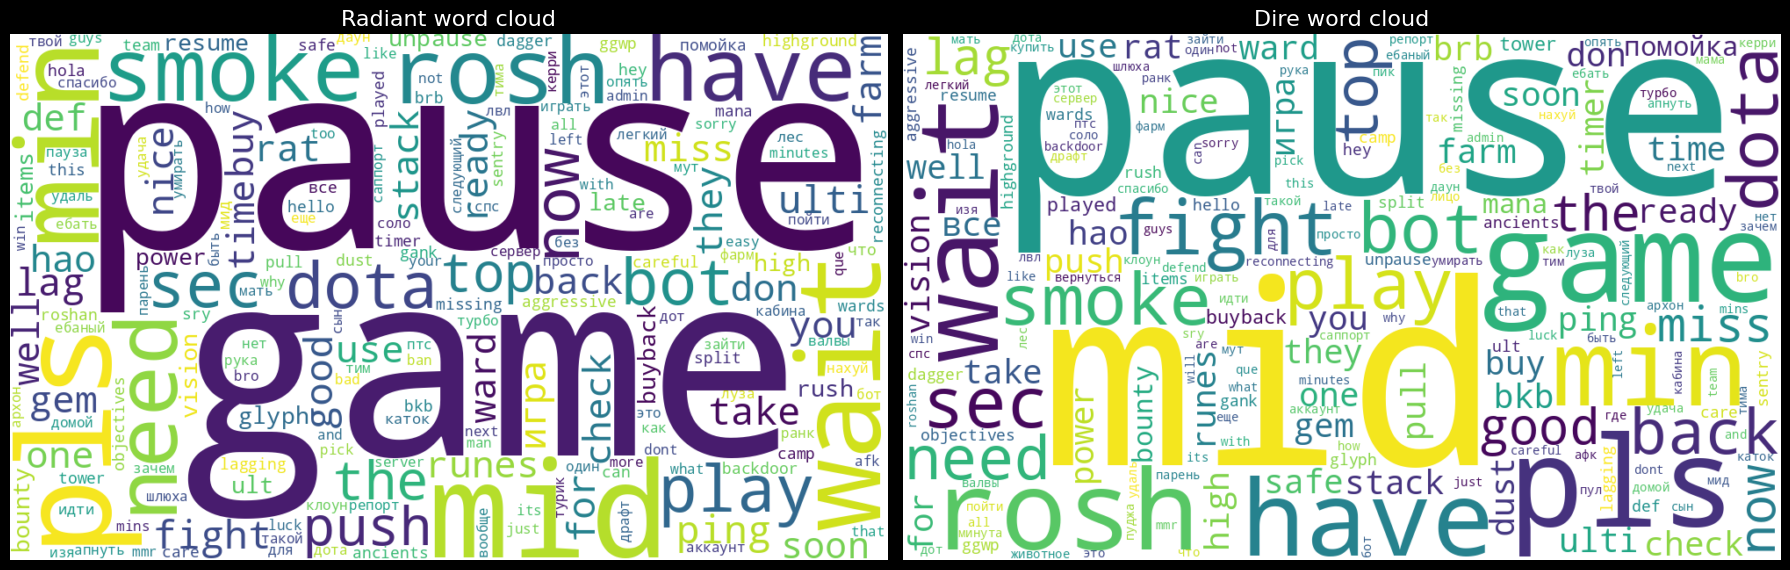

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(wc_radiant, interpolation="bilinear")
axes[0].set_title("Radiant word cloud", fontsize=16)
axes[0].axis("off")

axes[1].imshow(wc_dire, interpolation="bilinear")
axes[1].set_title("Dire word cloud", fontsize=16)
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [2]:
import polars as pl

In [3]:
df_train = pl.read_csv("matches_df_train.csv")

In [15]:
df_train = df_train.join(
    df_chat.select(["match_id", "radiant_tokens", "dire_tokens"]),
    on="match_id",
    how="left"
)

df_train

match_id,date,region,game_mode,duration,radiant_win,avg_mmr,radiant_tokens,dire_tokens
i64,str,str,i64,i64,bool,f64,list[str],list[str]
1,"""2024-02-12""","""Europe West""",4,2625,false,3519.7,[],[]
2,"""2024-04-08""","""South Africa""",2,7526,true,2330.9,[],[]
3,"""2024-06-16""","""SE Asia""",1,2831,true,1579.6,[],[]
4,"""2024-09-16""","""Middle East""",22,1438,false,null,[],[]
5,"""2024-03-31""","""South Africa""",22,2051,true,null,[],[]
…,…,…,…,…,…,…,…,…
767815,"""2024-07-13""","""US East""",1,1888,false,401.1,[],[]
767817,"""2024-02-02""","""China""",1,2789,false,null,[],[]
767818,"""2024-07-03""","""China""",2,1197,false,1953.4,[],[]


In [16]:
from collections import Counter
from itertools import chain
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [17]:
def flatten_token_lists(token_lists):
    return list(chain.from_iterable(token_lists))

In [18]:
def normalized_counter(words):
    cnt = Counter(words)
    total = sum(cnt.values())
    if total == 0:
        return {}
    return {word: freq / total for word, freq in cnt.items()}

In [19]:
def diff_frequencies(pos_words, neg_words, min_count=5):
    pos_cnt = Counter(pos_words)
    neg_cnt = Counter(neg_words)

    pos_norm = normalized_counter(pos_words)
    neg_norm = normalized_counter(neg_words)

    vocab = set(pos_cnt) | set(neg_cnt)

    pos_diff = {}
    neg_diff = {}

    for word in vocab:
        if pos_cnt[word] + neg_cnt[word] < min_count:
            continue

        score = pos_norm.get(word, 0.0) - neg_norm.get(word, 0.0)

        if score > 0:
            pos_diff[word] = score
        elif score < 0:
            neg_diff[word] = -score

    return pos_diff, neg_diff

In [20]:
def make_wordcloud(freq_dict, title, ax):
    wc = WordCloud(
        width=900,
        height=550,
        background_color="white",
        collocations=False,
        max_words=150,
    ).generate_from_frequencies(freq_dict)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=14)
    ax.axis("off")

In [21]:
radiant_win_df = df_train.filter(pl.col("radiant_win") == True)
radiant_lose_df = df_train.filter(pl.col("radiant_win") == False)

radiant_chat_win_words = flatten_token_lists(radiant_win_df["radiant_tokens"].to_list())
radiant_chat_lose_words = flatten_token_lists(radiant_lose_df["radiant_tokens"].to_list())

dire_chat_lose_words = flatten_token_lists(radiant_win_df["dire_tokens"].to_list())
dire_chat_win_words = flatten_token_lists(radiant_lose_df["dire_tokens"].to_list())

In [22]:
radiant_win_diff, radiant_lose_diff = diff_frequencies(
    radiant_chat_win_words,
    radiant_chat_lose_words,
    min_count=10
)

dire_win_diff, dire_lose_diff = diff_frequencies(
    dire_chat_win_words,
    dire_chat_lose_words,
    min_count=10
)

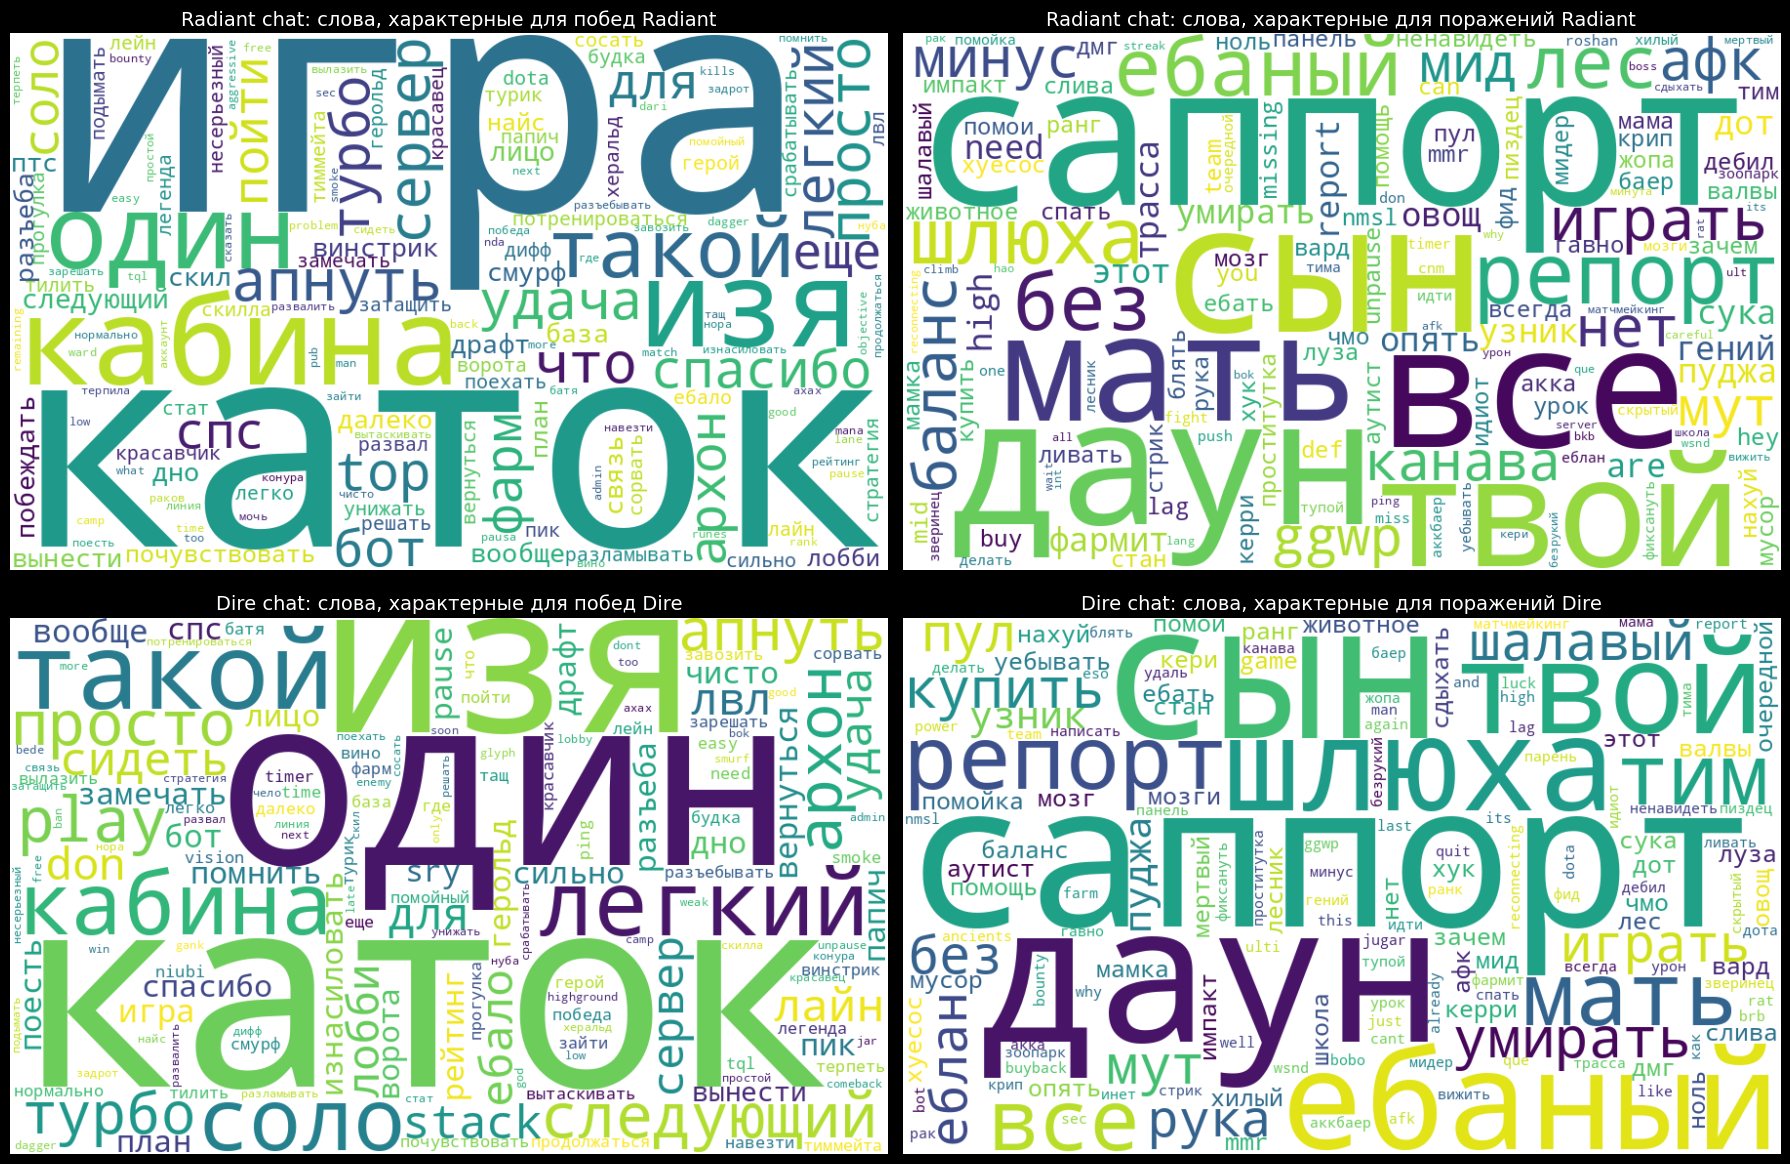

In [23]:

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

make_wordcloud(
    radiant_win_diff,
    "Radiant chat: слова, характерные для побед Radiant",
    axes[0, 0]
)

make_wordcloud(
    radiant_lose_diff,
    "Radiant chat: слова, характерные для поражений Radiant",
    axes[0, 1]
)

make_wordcloud(
    dire_win_diff,
    "Dire chat: слова, характерные для побед Dire",
    axes[1, 0]
)

make_wordcloud(
    dire_lose_diff,
    "Dire chat: слова, характерные для поражений Dire",
    axes[1, 1]
)

plt.tight_layout()
plt.show()

In [1]:
# %load_ext cudf.pandas
from hw3.pipeline_sota import FeatureSelection
from hw3.pipeline_sota import MyPipeline
import polars as pl
import joblib
import optuna

In [2]:
df_train = pl.read_csv("matches_df_train.csv")
df_test = pl.read_csv("matches_df_test.csv")
players_df = pl.read_csv("player_df.csv")
heroes_df = pl.read_csv("Constants.Heroes.csv")
chat_df = pl.read_csv("game_chat.csv")

In [28]:
# study = joblib.load("optuna_study.pkl")

In [3]:
def objective(trial):
    penalty = trial.suggest_categorical(
        "penalty",
        ["l1", "l2", "elasticnet", None],
    )
    text_params = {
        "text_max_features": trial.suggest_int("text_max_features", 1000, 5000, step=1000),
        "text_min_df": trial.suggest_int("text_min_df", 1, 20, step=1),
        "text_max_df": trial.suggest_float("text_max_df", 0.8, 1, step=0.01),
    }

    model_params = {

        "penalty": penalty,
        "C": trial.suggest_float("C", 1e-4, 1e2, log=True),

        "tol": trial.suggest_float("tol", 1e-6, 1e-2, log=True),
        "max_iter": trial.suggest_int("max_iter", 200, 3000, step=500),
        "linesearch_max_iter": trial.suggest_int(
            "linesearch_max_iter", 20, 100, step=10
        ),
        "lbfgs_memory": trial.suggest_int("lbfgs_memory", 3, 20),

        "class_weight": trial.suggest_categorical(
            "class_weight", [None, "balanced"]
        ),

        "solver": "qn",
    }

    if penalty == "elasticnet":
        model_params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)
    else:
        model_params["l1_ratio"] = None

    selection = FeatureSelection(
        enabled=(
            "game_mode_ohe",
            "region_ohe",
            "month_ohe",
            "is_weekend_ohe",
            "avg_mmr",
            "chat_tfidf"
        ),
        use_heroes=True,
        split_teams=True,
        mmr_transform="sqrt",
        text_max_features=text_params["text_max_features"],
        text_min_df=text_params["text_min_df"],
        text_max_df=text_params["text_max_df"],
    )
    pipe = MyPipeline(
        feature_selection=selection,
        n_splits=5,
        results_path="results.json",
        submission_path="submission.csv",
        target_col="radiant_win",
        preprocess_players=True,
        model_params=model_params,
    )

    result = pipe.run(
        df_train=df_train,
        df_test=df_test,
        players_df=players_df,
        heroes_df=heroes_df,
        chat_df=chat_df,
    )

    return result["cv_mean_gini"]

In [ ]:
study = optuna.create_study(direction="maximize")
# n_trials можно поставить и побольше, но пространство гиперпараметров здесь простое
study.optimize(objective, show_progress_bar=True, n_trials=25)

[I 2026-03-11 21:51:05,987] A new study created in memory with name: no-name-afba729c-72e9-4959-b8da-af6865d8e48a


  0%|          | 0/25 [00:00<?, ?it/s]

/tmp/ipykernel_28520/289593971.py:18: UserWarning: The distribution is specified by [200, 3000] and step=500, but the range is not divisible by `step`. It will be replaced with [200, 2700].
  "max_iter": trial.suggest_int("max_iter", 200, 3000, step=500),


  fold 1: Gini = 0.30657
  fold 2: Gini = 0.31068
  fold 3: Gini = 0.30262
  fold 4: Gini = 0.30770
  fold 5: Gini = 0.31116
  mean Gini = 0.30774
Saved submission: submission.csv
[I 2026-03-11 21:51:30,775] Trial 0 finished with value: 0.30774493217468263 and parameters: {'penalty': None, 'text_max_features': 1000, 'text_min_df': 2, 'text_max_df': 0.93, 'C': 0.0033570185707472605, 'tol': 3.3706961599396456e-05, 'max_iter': 1200, 'linesearch_max_iter': 40, 'lbfgs_memory': 17, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.30774493217468263.


/tmp/ipykernel_28520/289593971.py:18: UserWarning: The distribution is specified by [200, 3000] and step=500, but the range is not divisible by `step`. It will be replaced with [200, 2700].
  "max_iter": trial.suggest_int("max_iter", 200, 3000, step=500),


...

  fold 1: Gini = 0.31641
  fold 2: Gini = 0.32504
  fold 3: Gini = 0.31918
  fold 4: Gini = 0.32427
  fold 5: Gini = 0.33006
  mean Gini = 0.32299
[2026-03-11 21:53:06.860] [CUML] [warning] L-BFGS line search failed (code 3); stopping at the last valid step
Saved submission: submission.csv
[I 2026-03-11 21:53:06,942] Trial 3 finished with value: 0.32299199104309084 and parameters: {'penalty': 'l1', 'text_max_features': 2000, 'text_min_df': 9, 'text_max_df': 0.81, 'C': 13.544100035453258, 'tol': 0.0010606772938303703, 'max_iter': 2700, 'linesearch_max_iter': 30, 'lbfgs_memory': 18, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.324060320854187.


/tmp/ipykernel_28520/289593971.py:18: UserWarning: The distribution is specified by [200, 3000] and step=500, but the range is not divisible by `step`. It will be replaced with [200, 2700].
  "max_iter": trial.suggest_int("max_iter", 200, 3000, step=500),


  fold 1: Gini = 0.31933
  fold 2: Gini = 0.32650
  fold 3: Gini = 0.31981
[2026-03-11 21:53:27.467] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
  fold 4: Gini = 0.32617
  fold 5: Gini = 0.33113
  mean Gini = 0.32459
Saved submission: submission.csv
[I 2026-03-11 21:53:34,509] Trial 4 finished with value: 0.32458860874176027 and parameters: {'penalty': 'l2', 'text_max_features': 3000, 'text_min_df': 1, 'text_max_df': 0.8, 'C': 0.20072241312421527, 'tol': 0.0003630249937655902, 'max_iter': 1200, 'linesearch_max_iter': 50, 'lbfgs_memory': 16, 'class_weight': None}. Best is trial 4 with value: 0.32458860874176027.


/tmp/ipykernel_28520/289593971.py:18: UserWarning: The distribution is specified by [200, 3000] and step=500, but the range is not divisible by `step`. It will be replaced with [200, 2700].
  "max_iter": trial.suggest_int("max_iter", 200, 3000, step=500),


  fold 1: Gini = 0.31674
  fold 2: Gini = 0.32475
  fold 3: Gini = 0.31878
  fold 4: Gini = 0.32491
  fold 5: Gini = 0.33044
  mean Gini = 0.32313


In [7]:
import optuna.visualization as vis

In [ ]:
fig = vis.plot_parallel_coordinate(study)
fig.show()

In [8]:
fig = vis.plot_param_importances(study)
fig.show()

In [9]:
joblib.dump(study, "optuna_study_text_hyper.pkl")

['optuna_study_text_hyper.pkl']

In [5]:
text_study = joblib.load("optuna_study_text_hyper.pkl")

In [10]:
fig = vis.plot_slice(text_study)

fig.show()

In [11]:
fig = vis.plot_contour(text_study)

fig.show()

In [13]:
fig = vis.plot_parallel_coordinate(text_study)

fig.show()

In [14]:
fig = vis.plot_edf(text_study)

fig.show()

In [15]:
fig = vis.plot_rank(text_study)

fig.show()

In [16]:
fig = vis.plot_timeline(text_study)

fig.show()

In [1]:
from hw3.pipeline_sota import FeatureSelection
from hw3.pipeline_sota import MyPipeline
import polars as pl
import joblib

In [2]:
df_train = pl.read_csv("matches_df_train.csv")
df_test = pl.read_csv("matches_df_test.csv")
players_df = pl.read_csv("player_df.csv")
heroes_df = pl.read_csv("Constants.Heroes.csv")
chat_df = pl.read_csv("game_chat.csv")

In [3]:
text_study = joblib.load("optuna_study_text_hyper.pkl")

In [4]:
selection = FeatureSelection(
    enabled=(
        "game_mode_ohe",
        "region_ohe",
        "month_ohe",
        "is_weekend_ohe",
        "avg_mmr",
        "chat_tfidf"
    ),
    use_heroes=True,
    split_teams=True,
    mmr_transform="sqrt",
    text_max_features=text_study.best_params["text_max_features"],
    text_min_df=text_study.best_params["text_min_df"],
    text_max_df=text_study.best_params["text_max_df"],
)
pipe = MyPipeline(
    feature_selection=selection,
    n_splits=5,
    results_path="results.json",
    submission_path="submission.csv",
    target_col="radiant_win",
    preprocess_players=True,
    model_params=text_study.best_params,
)

result = pipe.run(
    df_train=df_train,
    df_test=df_test,
    players_df=players_df,
    heroes_df=heroes_df,
    chat_df=chat_df,
)

[2026-03-11 22:12:39.619] [CUML] [warning] L-BFGS: max iterations reached
[2026-03-11 22:12:39.629] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
  fold 1: Gini = 0.32089
[2026-03-11 22:12:42.375] [CUML] [warning] L-BFGS: max iterations reached
[2026-03-11 22:12:42.375] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
  fold 2: Gini = 0.32931
[2026-03-11 22:12:45.585] [CUML] [warning] L-BFGS: max iterations reached
[2026-03-11 22:12:45.595] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
  fold 3: Gini = 0.32135
[2026-03-11 22:12:50.555] [CUML] [warning] 

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что думаете? Сейчас и вообще по модели — негативные получились слова или так, едва?

**Ответ:** мистер негатив, когда проигрывают

</div>

### **Часть 5. Агрегации** (1.75 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4a/Techies_emoticon.gif/revision/latest?cb=20180504014918">

В которой студент начинает ведать

#### 📈 **Задание 5.1. Статистики матча** (0.75 балла)

Есть у нас в данных большой кусок про advantage — преимущество команды сил Света с точностью до минуты, по золоту и опыту, всё так же **в пределах 15 минут**. Лежат они в `dota_adv.csv`. Чем больше число, тем больше шанс на победу — всё просто. Только график, как правило, не линеен.

С ними в очередной раз есть *нюансы* — необходимо разобраться, как они там лежат, и всё ли там в порядке со значениями, но это меньшая из проблем. А также нарисовать парочку advantage, чтобы было понимание, как они себя ведут

In [1]:
# %load_ext cudf.pandas
# import pandas as pd

import polars as pl

In [2]:
dota_adv = pl.read_csv("dota_adv.csv")

In [3]:
dota_adv

match_id,radiant_gold_adv,radiant_exp_adv
i64,str,str
526846,"""[ 0 159 452 1904 2100 3290…","""[ 0 68 658 1397 1435 2118…"
511496,"""[ 0 -151 -141 12 -165 -151…","""[ 0 1 -136 243 -270 -8…"
90272,"""[]""","""[]"""
153647,"""[]""","""[]"""
694826,"""[]""","""[]"""
…,…,…
602640,"""[ 0 66 -5 -4 286…","""[ 0 -207 -558 -807 -686…"
757925,"""[ 0 32 -95 -58 -424…","""[ 0 76 217 133 -116 -412…"
700080,"""[]""","""[]"""


In [4]:
dota_adv.describe()

statistic,match_id,radiant_gold_adv,radiant_exp_adv
str,f64,str,str
"""count""",767822.0,"""767822""","""767822"""
"""null_count""",0.0,"""0""","""0"""
"""mean""",383910.5,null,null
"""std""",221651.263532,null,null
"""min""",0.0,"""[ 0 1214123728 1214123…","""[ 0 0 0 0 …"
"""25%""",191955.0,null,null
"""50%""",383911.0,null,null
"""75%""",575866.0,null,null
"""max""",767821.0,"""[]""","""[]"""


In [3]:
import re

In [4]:
def parse_cell(x):
    if x == "[]" or x is None:
        return []
    return list(map(int, re.findall(r'-?\d+', x)))

In [5]:
dota_adv = dota_adv.with_columns([
    pl.col("radiant_gold_adv").map_elements(parse_cell, return_dtype=pl.List(pl.Int64)),
    pl.col("radiant_exp_adv").map_elements(parse_cell, return_dtype=pl.List(pl.Int64)),
])

In [8]:
dota_adv

match_id,radiant_gold_adv,radiant_exp_adv
i64,list[i64],list[i64]
526846,"[0, 159, … 5342]","[0, 68, … 3311]"
511496,"[0, -151, … 3698]","[0, 1, … 201]"
90272,[],[]
153647,[],[]
694826,[],[]
…,…,…
602640,"[0, 66, … -143]","[0, -207, … 7743]"
757925,"[0, 32, … 823]","[0, 76, … 225]"
700080,[],[]


Для начала возьмём простые агрегации. Можете взять те, что вам знакомы (статистики - среднее, стд и др.), можете взять фан факты в вашей любимой библиотеке для данных, например [тут](https://pandas.pydata.org/docs/user_guide/groupby.html#aggregation) или [тут](https://docs.pola.rs/api/python/stable/reference/expressions/aggregation.html).

Задание:
- взять 4 статистики из библиотеки, применить к обеим колонкам `_adv`, <font color="#f68c9d">**обдумать**</font>, почему именно они
- одну из статистику выше разбить по командам, и точно так же примените к колонкам (получится что-то типа `agg_xp` -> `agg_dire_xp`, `agg_radiant_xp`)

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Тут мы встаём на скользкую дорожку переобучения. Агрегаций можно сделать **очень** много. Добавьте их все, и ваша модель превратится в тыкву. Удобнее будет сразу бить их на группы, например `features_last`, `features_q25`, `features_kurtosis_dire_10min+` и так далее, в зависимости от степени упоротости

C другой стороны, агрегации это самая сильная группа фичей, и для десяточки лучше целиться именно в них

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какие агрегации берём?

**Ответ:** среднее превосходство, последнее превосходство, пиковое превосходство и varience превосходства

</div>

Обучите модель по агрегациям (одной группе или нескольким) + предыдущим фичам. Чтобы получить фулл балл, придётся показать, что хотя бы минимальный импрув есть, относительно бейзлайна

In [6]:
import numpy as np

def to_array(x):
    if x is None:
        return np.array([], dtype=np.float64)

    if isinstance(x, pl.Series):
        x = x.to_list()

    if isinstance(x, (list, tuple, np.ndarray)) and len(x) > 0:
        return np.asarray(x, dtype=np.float64)

    return np.array([], dtype=np.float64)

def agg_mean(x):
    a = to_array(x)
    return np.nan if a.size == 0 else float(np.mean(a))

def agg_std(x):
    a = to_array(x)
    return np.nan if a.size == 0 else float(np.std(a))

def agg_last(x):
    a = to_array(x)
    return np.nan if a.size == 0 else float(a[-1])

def agg_abs_max(x):
    a = to_array(x)
    return np.nan if a.size == 0 else float(np.abs(a).max())

def agg_peak_radiant(x):
    a = to_array(x)
    return np.nan if a.size == 0 else float(np.clip(a, 0, None).max())

def agg_peak_dire(x):
    a = to_array(x)
    return np.nan if a.size == 0 else float(np.clip(-a, 0, None).max())


adv_cols = ["radiant_gold_adv", "radiant_exp_adv"]

exprs = [pl.col("match_id")]

for col in adv_cols:
    base = col.replace("radiant_", "")

    exprs.extend([
        pl.col(col).map_elements(agg_mean, return_dtype=pl.Float64).alias(f"mean_{base}"),
        pl.col(col).map_elements(agg_std, return_dtype=pl.Float64).alias(f"std_{base}"),
        pl.col(col).map_elements(agg_last, return_dtype=pl.Float64).alias(f"last_{base}"),
        pl.col(col).map_elements(agg_abs_max, return_dtype=pl.Float64).alias(f"abs_max_{base}"),
        pl.col(col).map_elements(agg_peak_radiant, return_dtype=pl.Float64).alias(f"peak_radiant_{base}"),
        pl.col(col).map_elements(agg_peak_dire, return_dtype=pl.Float64).alias(f"peak_dire_{base}"),
    ])

features_agg = dota_adv.select(exprs)

In [7]:
features_agg

match_id,mean_gold_adv,std_gold_adv,last_gold_adv,abs_max_gold_adv,peak_radiant_gold_adv,peak_dire_gold_adv,mean_exp_adv,std_exp_adv,last_exp_adv,abs_max_exp_adv,peak_radiant_exp_adv,peak_dire_exp_adv
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
526846,2887.5,1559.052797,5342.0,5342.0,5342.0,0.0,2262.25,1401.628406,3311.0,4661.0,4661.0,0.0
511496,933.875,1342.763702,3698.0,3698.0,3698.0,165.0,191.625,385.377717,201.0,931.0,931.0,270.0
90272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
694826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
…,…,…,…,…,…,…,…,…,…,…,…,…
602640,-66.0625,540.721332,-143.0,1589.0,564.0,1589.0,773.0625,2481.089818,7743.0,7743.0,7743.0,1178.0
757925,-104.9375,814.614746,823.0,1229.0,1229.0,1108.0,-69.0625,306.588378,225.0,713.0,225.0,713.0
700080,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
features_agg = features_agg.fill_nan(0.0)

In [13]:
features_agg

match_id,mean_gold_adv,std_gold_adv,last_gold_adv,abs_max_gold_adv,peak_radiant_gold_adv,peak_dire_gold_adv,mean_exp_adv,std_exp_adv,last_exp_adv,abs_max_exp_adv,peak_radiant_exp_adv,peak_dire_exp_adv
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
526846,2887.5,1559.052797,5342.0,5342.0,5342.0,0.0,2262.25,1401.628406,3311.0,4661.0,4661.0,0.0
511496,933.875,1342.763702,3698.0,3698.0,3698.0,165.0,191.625,385.377717,201.0,931.0,931.0,270.0
90272,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
153647,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
694826,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…
602640,-66.0625,540.721332,-143.0,1589.0,564.0,1589.0,773.0625,2481.089818,7743.0,7743.0,7743.0,1178.0
757925,-104.9375,814.614746,823.0,1229.0,1229.0,1108.0,-69.0625,306.588378,225.0,713.0,225.0,713.0
700080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

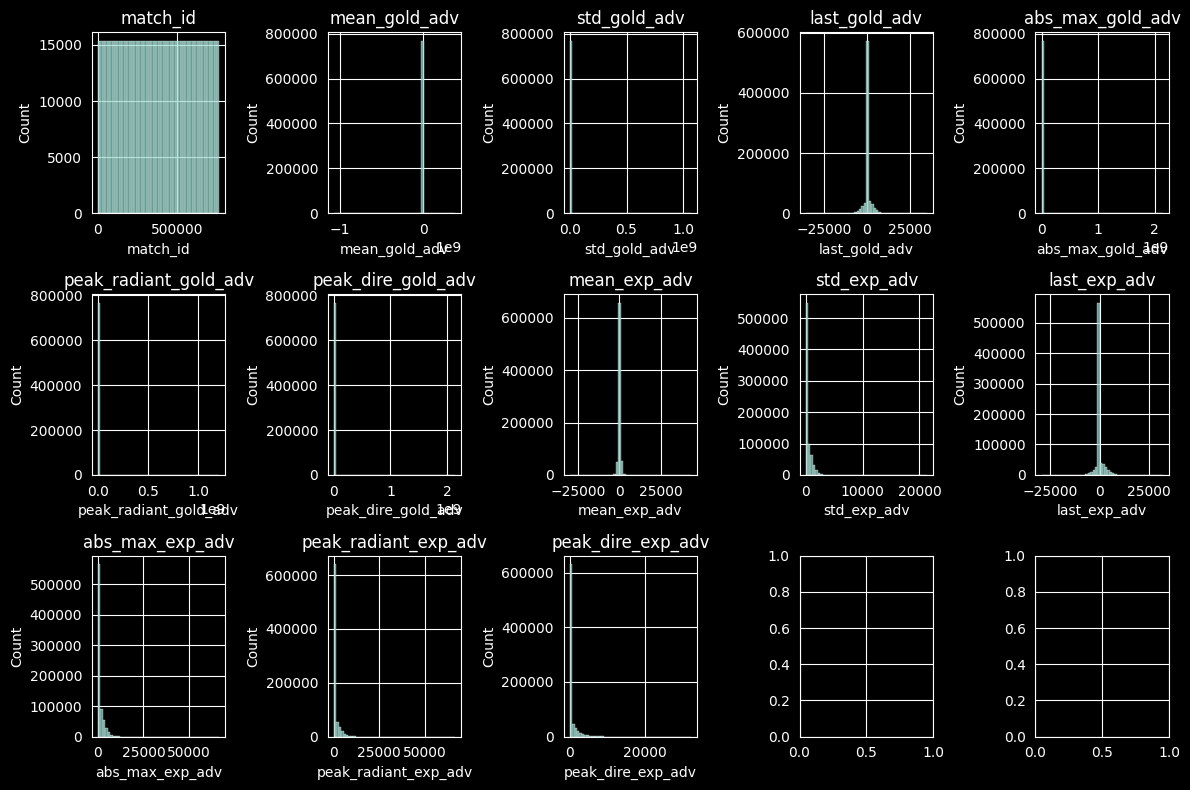

In [9]:
def draw_disrt(feat):
    df = feat.to_pandas()

    fig, axes = plt.subplots(3, 5, figsize=(12, 8))

    for ax, c in zip(axes.flatten(), features_agg.columns):
        sns.histplot(df[c], bins=50, ax=ax)
        ax.set_title(c)

    plt.tight_layout()
    plt.show()
draw_disrt(features_agg)

In [10]:
for col in set(features_agg.columns) - {"match_id"}:
    q_low = features_agg.select(pl.col(col).quantile(0.05)).item()
    q_high = features_agg.select(pl.col(col).quantile(0.95)).item()

    features_agg = features_agg.with_columns(
        pl.col(col).clip(q_low, q_high)
    )

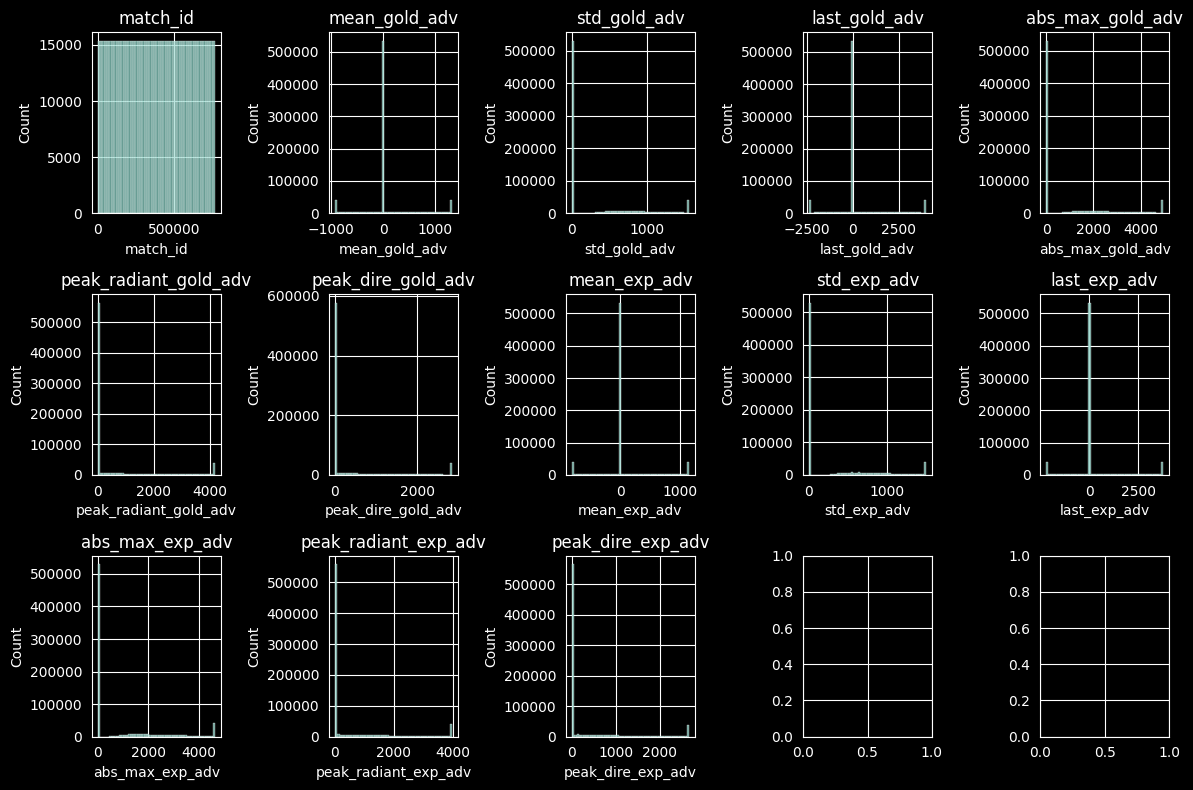

In [11]:
draw_disrt(features_agg)


In [12]:
pos_cols = [
    c for c in features_agg.columns
    if features_agg.select(pl.col(c).min()).item() > -1 and c != "match_id"
]

other_cols = [c for c in features_agg.columns if c not in pos_cols and c != "match_id"]

features_agg = features_agg.with_columns(
    [pl.col(c).log1p().alias(c) for c in pos_cols] +
    [pl.col(c).arcsinh().alias(c) for c in other_cols]
)

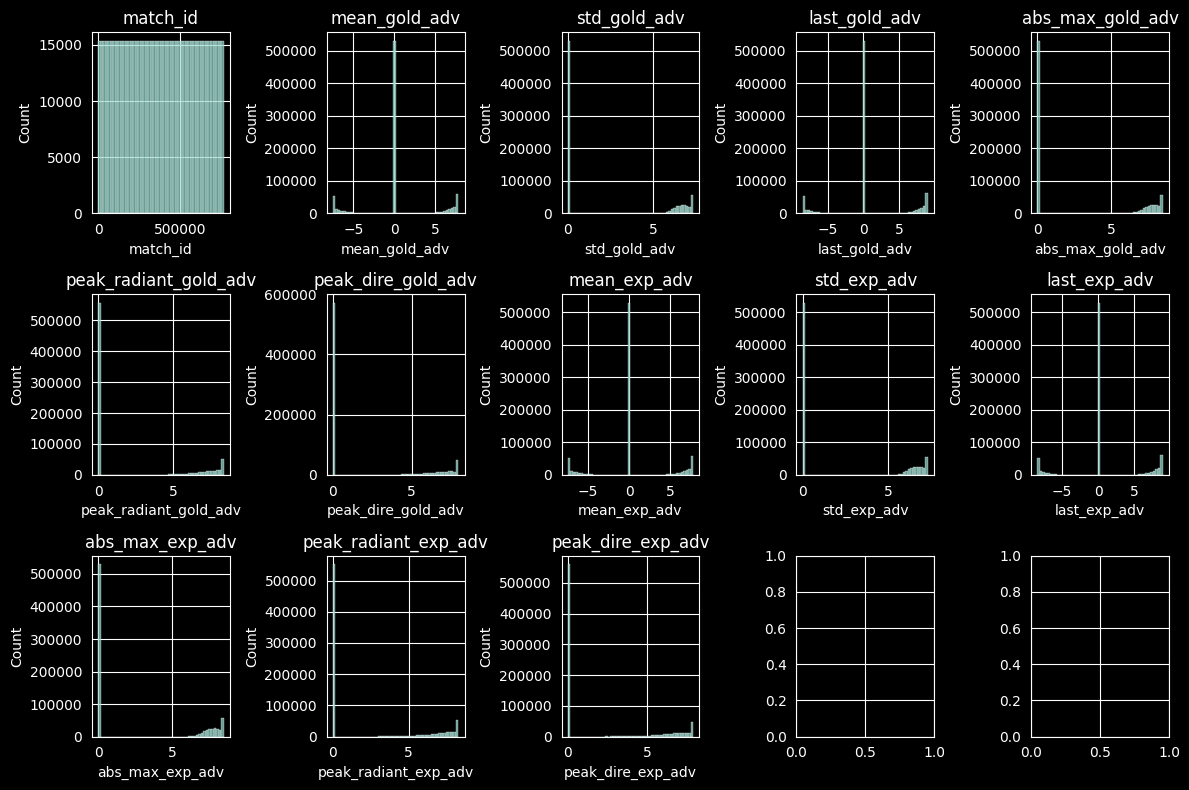

In [13]:
draw_disrt(features_agg)

In [14]:
cols = ["mean_gold_adv", "last_gold_adv", "mean_exp_adv", "last_exp_adv"]
features_agg = features_agg.with_columns([
    pl.col(c).clip(lower_bound=0).alias(f"radiant_{c}")
    for c in cols
] + [
    (-pl.col(c)).clip(lower_bound=0).alias(f"dire_{c}")
    for c in cols
]).drop(cols)

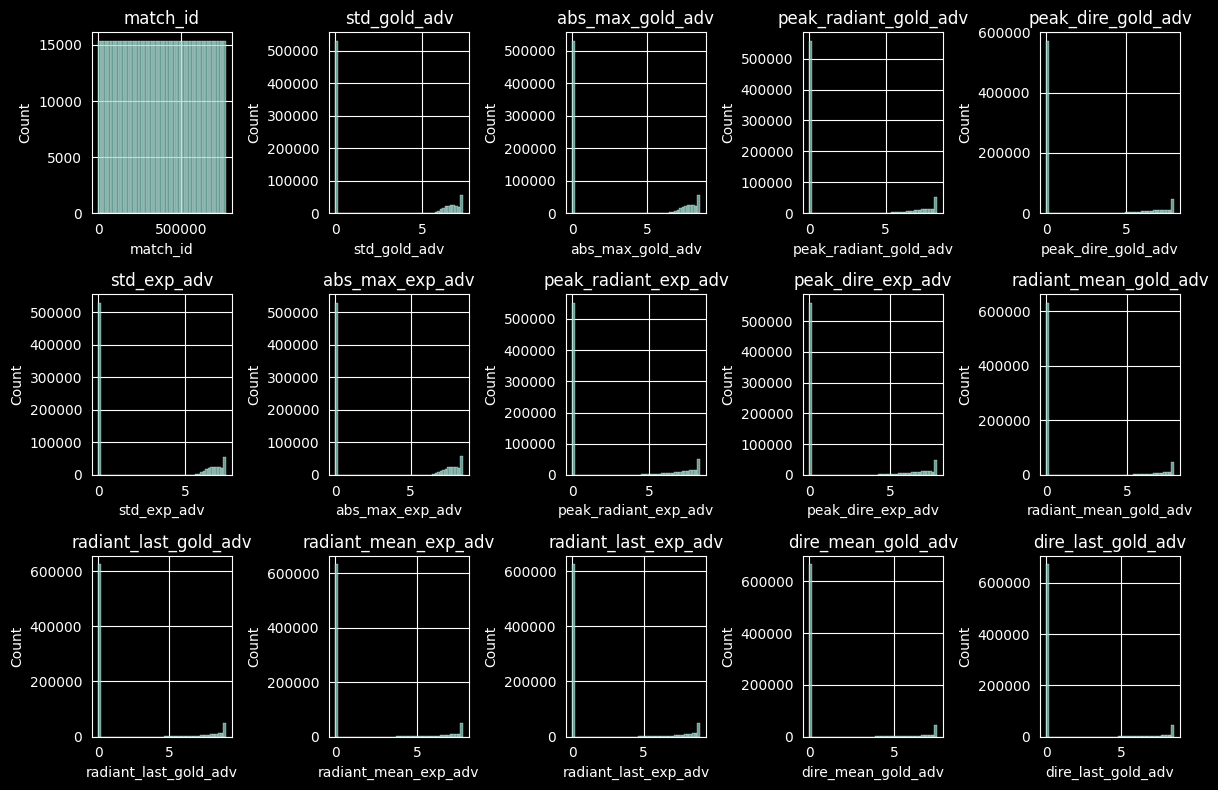

In [15]:
draw_disrt(features_agg)

In [16]:
features_agg

match_id,std_gold_adv,abs_max_gold_adv,peak_radiant_gold_adv,peak_dire_gold_adv,std_exp_adv,abs_max_exp_adv,peak_radiant_exp_adv,peak_dire_exp_adv,radiant_mean_gold_adv,radiant_last_gold_adv,radiant_mean_exp_adv,radiant_last_exp_adv,dire_mean_gold_adv,dire_last_gold_adv,dire_mean_exp_adv,dire_last_exp_adv
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
526846,7.350281,8.50593,8.340695,0.0,7.246103,8.444407,8.286773,0.0,7.87716,8.987697,7.748514,8.798153,0.0,0.0,0.0,0.0
511496,7.20323,8.215818,8.215818,5.111988,5.956815,6.837333,6.837333,5.602119,7.53249,8.908695,5.948694,5.996458,0.0,0.0,0.0,0.0
90272,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
153647,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
694826,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
602640,6.294752,7.371489,6.336826,7.371489,7.309614,8.444407,8.286773,7.072422,0.0,0.0,7.343507,8.927977,4.883806,5.656004,0.0,0.0
757925,6.703942,7.114769,7.114769,7.011214,5.728762,6.570883,5.420535,6.570883,0.0,7.406104,0.0,6.109253,5.346535,0.0,4.928211,0.0
700080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0


In [22]:
features_agg.write_csv("features_agg.csv")

In [1]:
import polars as pl
import joblib
import optuna

In [2]:
df_train = pl.read_csv("matches_df_train.csv")
df_test = pl.read_csv("matches_df_test.csv")
players_df = pl.read_csv("player_df.csv")
heroes_df = pl.read_csv("Constants.Heroes.csv")
chat_df = pl.read_csv("game_chat.csv")
features_agg = pl.read_csv("features_agg.csv")

In [3]:
df_train = df_train.join(features_agg, on="match_id", how="left")
df_test = df_test.join(features_agg, on="match_id", how="left")
df_train

match_id,date,region,game_mode,duration,radiant_win,avg_mmr,std_gold_adv,abs_max_gold_adv,peak_radiant_gold_adv,peak_dire_gold_adv,std_exp_adv,abs_max_exp_adv,peak_radiant_exp_adv,peak_dire_exp_adv,radiant_mean_gold_adv,radiant_last_gold_adv,radiant_mean_exp_adv,radiant_last_exp_adv,dire_mean_gold_adv,dire_last_gold_adv,dire_mean_exp_adv,dire_last_exp_adv
i64,str,str,i64,i64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,"""2024-02-12""","""Europe West""",4,2625,false,3519.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
2,"""2024-04-08""","""South Africa""",2,7526,true,2330.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
3,"""2024-06-16""","""SE Asia""",1,2831,true,1579.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
4,"""2024-09-16""","""Middle East""",22,1438,false,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
5,"""2024-03-31""","""South Africa""",22,2051,true,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
767815,"""2024-07-13""","""US East""",1,1888,false,401.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
767817,"""2024-02-02""","""China""",1,2789,false,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
767818,"""2024-07-03""","""China""",2,1197,false,1953.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0


In [4]:
df_test

match_id,date,region,game_mode,avg_mmr,std_gold_adv,abs_max_gold_adv,peak_radiant_gold_adv,peak_dire_gold_adv,std_exp_adv,abs_max_exp_adv,peak_radiant_exp_adv,peak_dire_exp_adv,radiant_mean_gold_adv,radiant_last_gold_adv,radiant_mean_exp_adv,radiant_last_exp_adv,dire_mean_gold_adv,dire_last_gold_adv,dire_mean_exp_adv,dire_last_exp_adv
i64,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8,"""2024-12-01""","""China""",1,2305.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
29,"""2024-12-17""","""Europe West""",22,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
34,"""2024-12-19""","""Europe West""",22,2278.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
36,"""2024-12-19""","""Europe West""",1,305.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
61,"""2024-12-06""","""Australia""",1,5142.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
767745,"""2024-12-05""","""South America""",1,4278.1,6.175157,7.226936,6.073045,7.226936,7.309614,8.444407,8.286773,6.418365,0.0,0.0,7.748514,8.927977,7.436028,7.661057,0.0,0.0
767755,"""2024-12-26""","""SE Asia""",22,3869.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
767795,"""2024-12-13""","""South America""",1,7437.2,6.924032,7.541152,7.078342,7.541152,6.782039,8.249052,4.691348,7.889084,0.0,7.469654,0.0,0.0,7.31197,0.0,7.403518,8.389814


In [4]:
text_study = joblib.load("optuna_study_text_hyper.pkl")

In [5]:
from hw3.pipeline_sota import FeatureSelection, MyPipeline

In [6]:
selection = FeatureSelection(
    enabled=(
        "game_mode_ohe",
        "region_ohe",
        "month_ohe",
        "is_weekend_ohe",
        "avg_mmr",
        "chat_tfidf",
        "aggregates"
    ),
    use_heroes=True,
    split_teams=True,
    mmr_transform="sqrt",
    text_max_features=text_study.best_params["text_max_features"],
    text_min_df=text_study.best_params["text_min_df"],
    text_max_df=text_study.best_params["text_max_df"],
)
pipe = MyPipeline(
    feature_selection=selection,
    n_splits=5,
    results_path="results.json",
    submission_path="submission.csv",
    target_col="radiant_win",
    preprocess_players=True,
    model_params=text_study.best_params,
)

result = pipe.run(
    df_train=df_train,
    df_test=df_test,
    players_df=players_df,
    heroes_df=heroes_df,
    chat_df=chat_df,
)

[2026-03-12 13:14:02.005] [CUML] [warning] L-BFGS: max iterations reached
[2026-03-12 13:14:02.011] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
  fold 1: Gini = 0.39521
[2026-03-12 13:14:05.531] [CUML] [warning] L-BFGS: max iterations reached
[2026-03-12 13:14:05.531] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
  fold 2: Gini = 0.40372
[2026-03-12 13:14:10.836] [CUML] [warning] L-BFGS: max iterations reached
[2026-03-12 13:14:10.836] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
  fold 3: Gini = 0.39865
[2026-03-12 13:14:18.107] [CUML] [warning] 

#### 📈 **Задание 5.2. Тренд** (0.5 балла)

Каждый уважающий себя лудоман знает, что 99% процентов игроков останавливается ровно перед тем, как сорвать джекпот. Так и здесь — если команда с треском проигрывает в первые 15 минут матча, возможно это признак камбека в следующие 50, как знать? Попробуем собрать агрегацию похитрее — она будет обозначать тренд, который есть в графиках преимущества, и если пословица верна, наша модель уловит эту зависимость.

<span style="color:grey"><font size="1">Администрация курса МО-1 категорически против азартных игр, пример приводится сугубо в образовательных целях.</font></span>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** для чего нам вообще тренд? Полезная ли это агрегация?

**Ответ:**

</div>

Агрегировать можно и вещи несколько более прикольные, чем те, что есть в основном функционале. Делать это мы будем, как вы наверняка догадались, трансформером, ну а чем же ещё. Что он умеет?

1. Принимает на вход функцию колонку и <font color="#cb9255">**параметры**</font> на ваш вкус, как минимум `method`, метод расчёта `slope`
2. Выделяет коэффициент наклона (`slope`, он же $\alpha$) при помощи одного из методов:
   - `'delta'`: разность первого и последнего значений $|x_{\max} - x_{\min}|$
   - `'OLS'`: линейная регрессия, обученная методом МНК $(X^TX)^{-1}X^Ty$
   - альтернативный метод, порождённый вашей бурной фантазией
3. Считает `r2` и `intercept` для одного advantage (если что это тоже могут быть наши фичи!)

In [22]:
from typing import Iterable
import cupy as cp
import polars as pl
from tqdm.auto import tqdm


class TrendTransformer:
    def __init__(self, columns: Iterable[str], method: str = "OLS"):
        self.columns = list(columns)
        self.method = method.upper()

        if self.method != "OLS":
            raise ValueError(f"Unsupported method: {method}")

    def fit(self, X: pl.DataFrame, y=None):
        return self

    @staticmethod
    def _to_numpy(values) -> np.ndarray:
        arr = np.asarray(values, dtype=float)

        if arr.ndim != 1:
            raise ValueError("Each cell must contain a 1D sequence of numbers")

        return arr
    @staticmethod
    def _to_cupy(values) -> cp.ndarray:
        arr = cp.asarray(values, dtype=float)
        if arr.ndim != 1:
            raise ValueError("Each cell must contain a 1D sequence of numbers")
        return arr

    def _calc_ols(self, values):
        y = self._to_cupy(values)

        mask = cp.isfinite(y)
        y = y[mask]

        if len(y) == 0:
            return cp.nan, cp.nan, cp.nan

        if len(y) == 1:
            return 0.0, float(y[0]), cp.nan

        x = cp.arange(len(y), dtype=float)

        x_mean = x.mean()
        y_mean = y.mean()

        denom = cp.sum((x - x_mean) ** 2)
        if denom == 0:
            slope = 0.0
        else:
            slope = cp.sum((x - x_mean) * (y - y_mean)) / denom

        intercept = y_mean - slope * x_mean
        y_pred = slope * x + intercept

        ss_res = cp.sum((y - y_pred) ** 2)
        ss_tot = cp.sum((y - y_mean) ** 2)

        if ss_tot == 0:
            r2 = 1.0 if ss_res == 0 else 0.0
        else:
            r2 = 1.0 - ss_res / ss_tot

        return float(slope), float(intercept), float(r2)

    def _calc_features(self, values):
        if self.method == "OLS":
            return self._calc_ols(values)

        raise ValueError(f"Unsupported method: {self.method}")

    def transform(self, X: pl.DataFrame, y=None) -> pl.DataFrame:
        if not isinstance(X, pl.DataFrame):
            raise TypeError("X must be a polars.DataFrame")

        missing = [col for col in self.columns if col not in X.columns]
        if missing:
            raise KeyError(f"Columns not found in X: {missing}")

        result = X.drop(self.columns)

        new_columns = []
        for col in self.columns:
            slopes = []
            intercepts = []
            r2s = []

            for values in tqdm(X.get_column(col).to_list(), desc=f"{col}"):
                slope, intercept, r2 = self._calc_features(values)
                slopes.append(slope)
                intercepts.append(intercept)
                r2s.append(r2)

            new_columns.extend(
                [
                    pl.Series(f"{col}_slope", slopes),
                    pl.Series(f"{col}_intercept", intercepts),
                    pl.Series(f"{col}_r2", r2s),
                ]
            )

        return result.with_columns(new_columns)

Реализуйте трансформер. Критерий успеха, вновь, качество — фича должна помочь, хотя бы на долю пункта

In [7]:
dota_adv = pl.read_csv("dota_adv.csv")

In [16]:
import re
def parse_cell(x):
    if x == "[]" or x is None:
        return []
    return list(map(int, re.findall(r'-?\d+', x)))


dota_adv = dota_adv.with_columns([
    pl.col("radiant_gold_adv").map_elements(parse_cell, return_dtype=pl.List(pl.Int64)),
    pl.col("radiant_exp_adv").map_elements(parse_cell, return_dtype=pl.List(pl.Int64)),
])
dota_adv

match_id,radiant_gold_adv,radiant_exp_adv
i64,list[i64],list[i64]
526846,"[0, 159, … 5342]","[0, 68, … 3311]"
511496,"[0, -151, … 3698]","[0, 1, … 201]"
90272,[],[]
153647,[],[]
694826,[],[]
…,…,…
602640,"[0, 66, … -143]","[0, -207, … 7743]"
757925,"[0, 32, … 823]","[0, 76, … 225]"
700080,[],[]


In [8]:
dota_adv.columns

['match_id', 'radiant_gold_adv', 'radiant_exp_adv']

In [24]:
cols = ['radiant_gold_adv', 'radiant_exp_adv']
transf = TrendTransformer(columns=cols)

In [25]:
out = transf.fit(dota_adv).transform(dota_adv)

radiant_gold_adv:   0%|          | 0/767822 [00:00<?, ?it/s]

radiant_exp_adv:   0%|          | 0/767822 [00:00<?, ?it/s]

In [26]:
out

match_id,radiant_gold_adv_slope,radiant_gold_adv_intercept,radiant_gold_adv_r2,radiant_exp_adv_slope,radiant_exp_adv_intercept,radiant_exp_adv_r2
i64,f64,f64,f64,f64,f64,f64
526846,304.388235,604.588235,0.810015,282.491176,143.566176,0.863183
511496,256.185294,-987.514706,0.773514,42.938235,-130.411765,0.2638
90272,NaN,NaN,NaN,NaN,NaN,NaN
153647,NaN,NaN,NaN,NaN,NaN,NaN
694826,NaN,NaN,NaN,NaN,NaN,NaN
…,…,…,…,…,…,…
602640,-50.063235,309.411765,0.182159,397.401471,-2207.448529,0.545171
757925,87.942647,-764.507353,0.247659,14.066176,-174.558824,0.04473
700080,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
out = out.with_columns([
    pl.when(pl.col(c).is_nan())
    .then(None)
    .otherwise(pl.col(c))
    .alias(c)
    for c in out.columns
    if c != "match_id"
])

In [28]:
out

match_id,radiant_gold_adv_slope,radiant_gold_adv_intercept,radiant_gold_adv_r2,radiant_exp_adv_slope,radiant_exp_adv_intercept,radiant_exp_adv_r2
i64,f64,f64,f64,f64,f64,f64
526846,304.388235,604.588235,0.810015,282.491176,143.566176,0.863183
511496,256.185294,-987.514706,0.773514,42.938235,-130.411765,0.2638
90272,null,null,null,null,null,null
153647,null,null,null,null,null,null
694826,null,null,null,null,null,null
…,…,…,…,…,…,…
602640,-50.063235,309.411765,0.182159,397.401471,-2207.448529,0.545171
757925,87.942647,-764.507353,0.247659,14.066176,-174.558824,0.04473
700080,null,null,null,null,null,null


In [29]:
out = out.with_columns(
    pl.any_horizontal([pl.col(c).is_null() for c in out.columns if c != "match_id"])
    .cast(pl.Int8)
    .alias("trend_was_imputed")
)

In [30]:
out

match_id,radiant_gold_adv_slope,radiant_gold_adv_intercept,radiant_gold_adv_r2,radiant_exp_adv_slope,radiant_exp_adv_intercept,radiant_exp_adv_r2,trend_was_imputed
i64,f64,f64,f64,f64,f64,f64,i8
526846,304.388235,604.588235,0.810015,282.491176,143.566176,0.863183,0
511496,256.185294,-987.514706,0.773514,42.938235,-130.411765,0.2638,0
90272,null,null,null,null,null,null,1
153647,null,null,null,null,null,null,1
694826,null,null,null,null,null,null,1
…,…,…,…,…,…,…,…
602640,-50.063235,309.411765,0.182159,397.401471,-2207.448529,0.545171,0
757925,87.942647,-764.507353,0.247659,14.066176,-174.558824,0.04473,0
700080,null,null,null,null,null,null,1


In [33]:
stats = out.select([
    pl.col(c).median().alias(c)
    for c in out.columns
    if c != "match_id"
]).row(0, named=True)
out = out.with_columns([
    pl.col(c).fill_null(stats[c]).alias(c)
    for c in out.columns
    if c != "match_id"
])

In [34]:
out

match_id,radiant_gold_adv_slope,radiant_gold_adv_intercept,radiant_gold_adv_r2,radiant_exp_adv_slope,radiant_exp_adv_intercept,radiant_exp_adv_r2,trend_was_imputed
i64,f64,f64,f64,f64,f64,f64,f64
526846,304.388235,604.588235,0.810015,282.491176,143.566176,0.863183,0.0
511496,256.185294,-987.514706,0.773514,42.938235,-130.411765,0.2638,0.0
90272,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0
153647,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0
694826,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0
…,…,…,…,…,…,…,…
602640,-50.063235,309.411765,0.182159,397.401471,-2207.448529,0.545171,0.0
757925,87.942647,-764.507353,0.247659,14.066176,-174.558824,0.04473,0.0
700080,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0


In [36]:
out.write_csv("trend_aggregate.csv")

In [37]:
out.columns

['match_id',
 'radiant_gold_adv_slope',
 'radiant_gold_adv_intercept',
 'radiant_gold_adv_r2',
 'radiant_exp_adv_slope',
 'radiant_exp_adv_intercept',
 'radiant_exp_adv_r2',
 'trend_was_imputed']

In [1]:
import polars as pl
import joblib
import optuna

In [2]:
df_train = pl.read_csv("matches_df_train.csv")
df_test = pl.read_csv("matches_df_test.csv")
players_df = pl.read_csv("player_df.csv")
heroes_df = pl.read_csv("Constants.Heroes.csv")
chat_df = pl.read_csv("game_chat.csv")
features_agg = pl.read_csv("features_agg.csv")
trend_agg = pl.read_csv("trend_aggregate.csv")

In [3]:
df_train = df_train.join(features_agg, on="match_id", how="left")
df_test = df_test.join(features_agg, on="match_id", how="left")
df_train = df_train.join(trend_agg, on="match_id", how="left")
df_test = df_test.join(trend_agg, on="match_id", how="left")

In [4]:
df_train

match_id,date,region,game_mode,duration,radiant_win,avg_mmr,std_gold_adv,abs_max_gold_adv,peak_radiant_gold_adv,peak_dire_gold_adv,std_exp_adv,abs_max_exp_adv,peak_radiant_exp_adv,peak_dire_exp_adv,radiant_mean_gold_adv,radiant_last_gold_adv,radiant_mean_exp_adv,radiant_last_exp_adv,dire_mean_gold_adv,dire_last_gold_adv,dire_mean_exp_adv,dire_last_exp_adv,radiant_gold_adv_slope,radiant_gold_adv_intercept,radiant_gold_adv_r2,radiant_exp_adv_slope,radiant_exp_adv_intercept,radiant_exp_adv_r2,trend_was_imputed
i64,str,str,i64,i64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,"""2024-02-12""","""Europe West""",4,2625,false,3519.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0
2,"""2024-04-08""","""South Africa""",2,7526,true,2330.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0
3,"""2024-06-16""","""SE Asia""",1,2831,true,1579.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0
4,"""2024-09-16""","""Middle East""",22,1438,false,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0
5,"""2024-03-31""","""South Africa""",22,2051,true,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
767815,"""2024-07-13""","""US East""",1,1888,false,401.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0
767817,"""2024-02-02""","""China""",1,2789,false,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0
767818,"""2024-07-03""","""China""",2,1197,false,1953.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0


In [4]:
text_study = joblib.load("optuna_study_text_hyper.pkl")
from hw3.pipeline_sota import FeatureSelection, MyPipeline

In [5]:
selection = FeatureSelection(
    enabled=(
        "game_mode_ohe",
        "region_ohe",
        "month_ohe",
        "is_weekend_ohe",
        "avg_mmr",
        "chat_tfidf",
        "aggregates",
        "aggregates_trend"
    ),
    use_heroes=True,
    split_teams=True,
    mmr_transform="sqrt",
    text_max_features=text_study.best_params["text_max_features"],
    text_min_df=text_study.best_params["text_min_df"],
    text_max_df=text_study.best_params["text_max_df"],
)
pipe = MyPipeline(
    feature_selection=selection,
    n_splits=5,
    results_path="results.json",
    submission_path="submission.csv",
    target_col="radiant_win",
    preprocess_players=True,
    model_params=text_study.best_params,
)

result = pipe.run(
    df_train=df_train,
    df_test=df_test,
    players_df=players_df,
    heroes_df=heroes_df,
    chat_df=chat_df,
)

[2026-03-12 13:58:29.061] [CUML] [warning] L-BFGS: max iterations reached
[2026-03-12 13:58:29.062] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
  fold 1: Gini = 0.39837
[2026-03-12 13:58:32.758] [CUML] [warning] L-BFGS: max iterations reached
[2026-03-12 13:58:32.758] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
  fold 2: Gini = 0.40312
[2026-03-12 13:58:39.524] [CUML] [warning] L-BFGS: max iterations reached
[2026-03-12 13:58:39.524] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
  fold 3: Gini = 0.39859
[2026-03-12 13:58:48.692] [CUML] [warning] 

#### **📈 Задание 5.3. Бинаризация** (0.5 балла)

Ровно одну прикольную фишку для числовых признаков мы пока что не рассмотрели — бинаризацию. Если вы до неё уже догадались, то вы — гений, не думали на <font color="cb9255">**МОП**</font>? А если нет, суть такова:

1. Берём отрезок advantage и бьём его на несколько бинов
2. Бины можно использовать, как фичу саму по себе, а можно подсобрать внутри неё агрегации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Во-первых, ваша модель внезапно становится нелинейной, хоть и кусочной, это полный отвал \
Во-вторых, это простейший пример ансамбля, если бинаризовать таргет (но у нас, увы нет смысла, он дискретный). Нелинейность полезна почему — в первые минуты преимущество не так решает, как в последние. \
В-третьих, это фильтрует шумный сигнал, выбросы то отлетят в соответствующий бин

</div>

Попробуем? Бинаризуйте признаки advantage: занумеруйте их (сделайте категорию) и посчитайте побиновые агрегации

In [1]:
import polars as pl
import re

In [2]:
dota_adv = pl.read_csv("dota_adv.csv")

In [3]:
def parse_cell(x):
    if x == "[]" or x is None:
        return []
    return list(map(int, re.findall(r"-?\d+", x)))


base_df = (
    dota_adv
    .with_row_index("row_id")
    .with_columns([
        pl.col("radiant_gold_adv").map_elements(parse_cell, return_dtype=pl.List(pl.Int64)),
        pl.col("radiant_exp_adv").map_elements(parse_cell, return_dtype=pl.List(pl.Int64)),
    ])
)

In [4]:
base_df

row_id,match_id,radiant_gold_adv,radiant_exp_adv
u32,i64,list[i64],list[i64]
0,526846,"[0, 159, … 5342]","[0, 68, … 3311]"
1,511496,"[0, -151, … 3698]","[0, 1, … 201]"
2,90272,[],[]
3,153647,[],[]
4,694826,[],[]
…,…,…,…
767817,602640,"[0, 66, … -143]","[0, -207, … 7743]"
767818,757925,"[0, 32, … 823]","[0, 76, … 225]"
767819,700080,[],[]


In [5]:
gold_step = 500
exp_step = 500

long_df = (
    base_df
    .with_columns(
        pl.int_ranges(1, pl.col("radiant_gold_adv").list.len() + 1).alias("minute")
    )
    .explode(["minute", "radiant_gold_adv", "radiant_exp_adv"])
    .rename({
        "radiant_gold_adv": "gold_adv",
        "radiant_exp_adv": "exp_adv",
    })
    .with_columns([
        (pl.col("gold_adv") / gold_step).floor().clip(-20, 20).cast(pl.Int16).alias("gold_bin"),
        (pl.col("exp_adv") / exp_step).floor().clip(-20, 20).cast(pl.Int16).alias("exp_bin"),
    ])
)


In [6]:
long_df

row_id,match_id,gold_adv,exp_adv,minute,gold_bin,exp_bin
u32,i64,i64,i64,i64,i16,i16
0,526846,0,0,1,0,0
0,526846,159,68,2,0,0
0,526846,452,658,3,0,1
0,526846,1904,1397,4,3,2
0,526846,2100,1435,5,4,2
…,…,…,…,…,…,…
767818,757925,1229,225,15,2,0
767818,757925,823,225,16,1,0
767819,700080,null,null,null,null,null


In [6]:
checkpoints = [5, 10, 15, 20]

checkpoint_feats = (
    long_df
    .group_by("match_id")
    .agg(
        [pl.col("gold_bin").filter(pl.col("minute") == m).first().alias(f"gold_bin_m{m}") for m in checkpoints] +
        [pl.col("exp_bin").filter(pl.col("minute") == m).first().alias(f"exp_bin_m{m}") for m in checkpoints]
    )
)

In [11]:
checkpoint_feats

match_id,gold_bin_m5,gold_bin_m10,gold_bin_m15,gold_bin_m20,exp_bin_m5,exp_bin_m10,exp_bin_m15,exp_bin_m20
i64,i16,i16,i16,i16,i16,i16,i16,i16
506657,0,0,6,null,-1,0,5,null
65575,null,null,null,null,null,null,null,null
101088,null,null,null,null,null,null,null,null
46449,null,null,null,null,null,null,null,null
501670,1,2,2,null,-2,-4,-3,null
…,…,…,…,…,…,…,…,…
489183,0,-2,-3,null,0,-1,1,null
569656,-4,-5,-8,null,-4,-5,-7,null
249836,null,null,null,null,null,null,null,null


In [7]:
summary_feats = (
    long_df
    .group_by("match_id")
    .agg([
        pl.col("gold_adv").mean().alias("gold_adv_mean"),
        pl.col("gold_adv").std().alias("gold_adv_std"),
        pl.col("gold_adv").min().alias("gold_adv_min"),
        pl.col("gold_adv").max().alias("gold_adv_max"),

        pl.col("exp_adv").mean().alias("exp_adv_mean"),
        pl.col("exp_adv").std().alias("exp_adv_std"),
        pl.col("exp_adv").min().alias("exp_adv_min"),
        pl.col("exp_adv").max().alias("exp_adv_max"),

        (pl.col("gold_adv") > 0).mean().alias("share_gold_positive"),
        (pl.col("exp_adv") > 0).mean().alias("share_exp_positive"),

        pl.col("gold_bin").last().alias("gold_bin_last"),
        pl.col("exp_bin").last().alias("exp_bin_last"),
    ])
)

In [8]:
summary_feats

match_id,gold_adv_mean,gold_adv_std,gold_adv_min,gold_adv_max,exp_adv_mean,exp_adv_std,exp_adv_min,exp_adv_max,share_gold_positive,share_exp_positive,gold_bin_last,exp_bin_last
i64,f64,f64,i64,i64,f64,f64,i64,i64,f64,f64,i16,i16
349239,null,null,null,null,null,null,null,null,null,null,null,null
593692,3023.9375,1670.91793,0,7010,1593.5625,979.509875,0,3719,0.9375,0.9375,14,6
130450,null,null,null,null,null,null,null,null,null,null,null,null
192440,null,null,null,null,null,null,null,null,null,null,null,null
421045,-130.5625,350.956592,-747,982,1010.625,841.17734,-104,2170,0.0625,0.875,1,4
…,…,…,…,…,…,…,…,…,…,…,…,…
532830,-2921.375,4645.331203,-12161,503,-930.625,993.221686,-2926,185,0.25,0.0625,-20,-6
287829,null,null,null,null,null,null,null,null,null,null,null,null
412077,-208.75,598.596525,-1401,551,-786.0,1646.69309,-5635,616,0.4375,0.1875,-1,-12


In [9]:
train_df = (
    base_df
    .join(checkpoint_feats, on="match_id", how="left")
    .join(summary_feats, on="match_id", how="left")
)

In [10]:
hist_cols = [c for c in train_df.columns if c.startswith("gold_bin_share_") or c.startswith("exp_bin_share_")]

other_num_cols = [
    c for c, dt in train_df.schema.items()
    if c not in hist_cols
    and c not in ["row_id", "match_id", "radiant_gold_adv", "radiant_exp_adv"]
    and dt in [pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64, pl.Float32, pl.Float64]
]

train_df = train_df.with_columns(
    [pl.col(c).fill_null(0) for c in hist_cols] +
    [pl.col(c).fill_null(pl.col(c).median()) for c in other_num_cols]
)

In [11]:
train_df

row_id,match_id,radiant_gold_adv,radiant_exp_adv,gold_bin_m5,gold_bin_m10,gold_bin_m15,gold_bin_m20,exp_bin_m5,exp_bin_m10,exp_bin_m15,exp_bin_m20,gold_adv_mean,gold_adv_std,gold_adv_min,gold_adv_max,exp_adv_mean,exp_adv_std,exp_adv_min,exp_adv_max,share_gold_positive,share_exp_positive,gold_bin_last,exp_bin_last
u32,i64,list[i64],list[i64],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,526846,"[0, 159, … 5342]","[0, 68, … 3311]",4.0,7.0,10.0,null,2.0,3.0,9.0,null,2887.5,1610.182805,0.0,5342.0,2262.25,1447.595593,0.0,4661.0,0.9375,0.9375,10.0,6.0
1,511496,"[0, -151, … 3698]","[0, 1, … 201]",-1.0,0.0,7.0,null,-1.0,0.0,0.0,null,933.875,1386.800388,-165.0,3698.0,191.625,398.016394,-270.0,931.0,0.625,0.5625,7.0,0.0
2,90272,[],[],0.0,0.0,1.0,null,-1.0,0.0,1.0,null,202.1875,920.055786,-863.0,1578.0,164.875,883.625352,-865.0,1507.0,0.5,0.5,1.0,1.0
3,153647,[],[],0.0,0.0,1.0,null,-1.0,0.0,1.0,null,202.1875,920.055786,-863.0,1578.0,164.875,883.625352,-865.0,1507.0,0.5,0.5,1.0,1.0
4,694826,[],[],0.0,0.0,1.0,null,-1.0,0.0,1.0,null,202.1875,920.055786,-863.0,1578.0,164.875,883.625352,-865.0,1507.0,0.5,0.5,1.0,1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
767817,602640,"[0, 66, … -143]","[0, -207, … 7743]",0.0,0.0,-1.0,null,-2.0,-2.0,9.0,null,-66.0625,558.45459,-1589.0,564.0,773.0625,2562.458545,-1178.0,7743.0,0.4375,0.3125,-1.0,15.0
767818,757925,"[0, 32, … 823]","[0, 76, … 225]",-1.0,-2.0,2.0,null,-1.0,-1.0,0.0,null,-104.9375,841.330491,-1108.0,1229.0,-69.0625,316.643115,-713.0,225.0,0.3125,0.5,1.0,0.0
767819,700080,[],[],0.0,0.0,1.0,null,-1.0,0.0,1.0,null,202.1875,920.055786,-863.0,1578.0,164.875,883.625352,-865.0,1507.0,0.5,0.5,1.0,1.0


In [13]:
train_df = train_df.drop("row_id", "radiant_gold_adv", "radiant_exp_adv", "gold_bin_m20", "exp_bin_m20")

In [14]:
train_df

match_id,gold_bin_m5,gold_bin_m10,gold_bin_m15,exp_bin_m5,exp_bin_m10,exp_bin_m15,gold_adv_mean,gold_adv_std,gold_adv_min,gold_adv_max,exp_adv_mean,exp_adv_std,exp_adv_min,exp_adv_max,share_gold_positive,share_exp_positive,gold_bin_last,exp_bin_last
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
526846,4.0,7.0,10.0,2.0,3.0,9.0,2887.5,1610.182805,0.0,5342.0,2262.25,1447.595593,0.0,4661.0,0.9375,0.9375,10.0,6.0
511496,-1.0,0.0,7.0,-1.0,0.0,0.0,933.875,1386.800388,-165.0,3698.0,191.625,398.016394,-270.0,931.0,0.625,0.5625,7.0,0.0
90272,0.0,0.0,1.0,-1.0,0.0,1.0,202.1875,920.055786,-863.0,1578.0,164.875,883.625352,-865.0,1507.0,0.5,0.5,1.0,1.0
153647,0.0,0.0,1.0,-1.0,0.0,1.0,202.1875,920.055786,-863.0,1578.0,164.875,883.625352,-865.0,1507.0,0.5,0.5,1.0,1.0
694826,0.0,0.0,1.0,-1.0,0.0,1.0,202.1875,920.055786,-863.0,1578.0,164.875,883.625352,-865.0,1507.0,0.5,0.5,1.0,1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
602640,0.0,0.0,-1.0,-2.0,-2.0,9.0,-66.0625,558.45459,-1589.0,564.0,773.0625,2562.458545,-1178.0,7743.0,0.4375,0.3125,-1.0,15.0
757925,-1.0,-2.0,2.0,-1.0,-1.0,0.0,-104.9375,841.330491,-1108.0,1229.0,-69.0625,316.643115,-713.0,225.0,0.3125,0.5,1.0,0.0
700080,0.0,0.0,1.0,-1.0,0.0,1.0,202.1875,920.055786,-863.0,1578.0,164.875,883.625352,-865.0,1507.0,0.5,0.5,1.0,1.0


In [15]:
train_df.write_csv("features_bin.csv")

In [16]:
train_df.columns

['match_id',
 'gold_bin_m5',
 'gold_bin_m10',
 'gold_bin_m15',
 'exp_bin_m5',
 'exp_bin_m10',
 'exp_bin_m15',
 'gold_adv_mean',
 'gold_adv_std',
 'gold_adv_min',
 'gold_adv_max',
 'exp_adv_mean',
 'exp_adv_std',
 'exp_adv_min',
 'exp_adv_max',
 'share_gold_positive',
 'share_exp_positive',
 'gold_bin_last',
 'exp_bin_last']

In [1]:
import polars as pl
import joblib
import optuna

In [2]:
df_train = pl.read_csv("matches_df_train.csv")
df_test = pl.read_csv("matches_df_test.csv")
players_df = pl.read_csv("player_df.csv")
heroes_df = pl.read_csv("Constants.Heroes.csv")
chat_df = pl.read_csv("game_chat.csv")
features_agg = pl.read_csv("features_agg.csv")
trend_agg = pl.read_csv("trend_aggregate.csv")
features_bin = pl.read_csv("features_bin.csv")

In [3]:
df_train = df_train.join(features_agg, on="match_id", how="left")
df_test = df_test.join(features_agg, on="match_id", how="left")
df_train = df_train.join(trend_agg, on="match_id", how="left")
df_test = df_test.join(trend_agg, on="match_id", how="left")

df_train = df_train.join(features_bin, on="match_id", how="left")
df_test = df_test.join(features_bin, on="match_id", how="left")

In [4]:
df_train

match_id,date,region,game_mode,duration,radiant_win,avg_mmr,std_gold_adv,abs_max_gold_adv,peak_radiant_gold_adv,peak_dire_gold_adv,std_exp_adv,abs_max_exp_adv,peak_radiant_exp_adv,peak_dire_exp_adv,radiant_mean_gold_adv,radiant_last_gold_adv,radiant_mean_exp_adv,radiant_last_exp_adv,dire_mean_gold_adv,dire_last_gold_adv,dire_mean_exp_adv,dire_last_exp_adv,radiant_gold_adv_slope,radiant_gold_adv_intercept,radiant_gold_adv_r2,radiant_exp_adv_slope,radiant_exp_adv_intercept,radiant_exp_adv_r2,trend_was_imputed,gold_bin_m5,gold_bin_m10,gold_bin_m15,exp_bin_m5,exp_bin_m10,exp_bin_m15,gold_adv_mean,gold_adv_std,gold_adv_min,gold_adv_max,exp_adv_mean,exp_adv_std,exp_adv_min,exp_adv_max,share_gold_positive,share_exp_positive,gold_bin_last,exp_bin_last
i64,str,str,i64,i64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,"""2024-02-12""","""Europe West""",4,2625,false,3519.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0,0.0,0.0,1.0,-1.0,0.0,1.0,202.1875,920.055786,-863.0,1578.0,164.875,883.625352,-865.0,1507.0,0.5,0.5,1.0,1.0
2,"""2024-04-08""","""South Africa""",2,7526,true,2330.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0,0.0,0.0,1.0,-1.0,0.0,1.0,202.1875,920.055786,-863.0,1578.0,164.875,883.625352,-865.0,1507.0,0.5,0.5,1.0,1.0
3,"""2024-06-16""","""SE Asia""",1,2831,true,1579.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0,0.0,0.0,1.0,-1.0,0.0,1.0,202.1875,920.055786,-863.0,1578.0,164.875,883.625352,-865.0,1507.0,0.5,0.5,1.0,1.0
4,"""2024-09-16""","""Middle East""",22,1438,false,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0,0.0,0.0,1.0,-1.0,0.0,1.0,202.1875,920.055786,-863.0,1578.0,164.875,883.625352,-865.0,1507.0,0.5,0.5,1.0,1.0
5,"""2024-03-31""","""South Africa""",22,2051,true,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0,0.0,0.0,1.0,-1.0,0.0,1.0,202.1875,920.055786,-863.0,1578.0,164.875,883.625352,-865.0,1507.0,0.5,0.5,1.0,1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
767815,"""2024-07-13""","""US East""",1,1888,false,401.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0,0.0,0.0,1.0,-1.0,0.0,1.0,202.1875,920.055786,-863.0,1578.0,164.875,883.625352,-865.0,1507.0,0.5,0.5,1.0,1.0
767817,"""2024-02-02""","""China""",1,2789,false,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0,0.0,0.0,1.0,-1.0,0.0,1.0,202.1875,920.055786,-863.0,1578.0,164.875,883.625352,-865.0,1507.0,0.5,0.5,1.0,1.0
767818,"""2024-07-03""","""China""",2,1197,false,1953.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,48.285294,-158.110294,0.494092,47.016176,-190.860294,0.480657,1.0,0.0,0.0,1.0,-1.0,0.0,1.0,202.1875,920.055786,-863.0,1578.0,164.875,883.625352,-865.0,1507.0,0.5,0.5,1.0,1.0


In [5]:
text_study = joblib.load("optuna_study_text_hyper.pkl")
from hw3.pipeline_sota import FeatureSelection, MyPipeline

In [6]:
selection = FeatureSelection(
    enabled=(
        "game_mode_ohe",
        "region_ohe",
        "month_ohe",
        "is_weekend_ohe",
        "avg_mmr",
        "chat_tfidf",
        "aggregates",
        "aggregates_trend",
        "features_bin"
    ),
    use_heroes=True,
    split_teams=True,
    mmr_transform="sqrt",
    text_max_features=text_study.best_params["text_max_features"],
    text_min_df=text_study.best_params["text_min_df"],
    text_max_df=text_study.best_params["text_max_df"],
)
pipe = MyPipeline(
    feature_selection=selection,
    n_splits=5,
    results_path="results.json",
    submission_path="submission.csv",
    target_col="radiant_win",
    preprocess_players=True,
    model_params=text_study.best_params,
)

result = pipe.run(
    df_train=df_train,
    df_test=df_test,
    players_df=players_df,
    heroes_df=heroes_df,
    chat_df=chat_df,
)

[2026-03-12 14:55:55.070] [CUML] [warning] L-BFGS: max iterations reached
[2026-03-12 14:55:55.070] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
  fold 1: Gini = 0.40252
[2026-03-12 14:55:59.494] [CUML] [warning] L-BFGS: max iterations reached
[2026-03-12 14:55:59.494] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
  fold 2: Gini = 0.40983
[2026-03-12 14:56:05.520] [CUML] [warning] L-BFGS: max iterations reached
[2026-03-12 14:56:05.520] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
  fold 3: Gini = 0.40531
[2026-03-12 14:56:17.838] [CUML] [warning] 

### **Часть 6. Около ML** (2 балла) <img height=25px width=35px align="center" src="https://media1.tenor.com/m/72ScVNgTGpYAAAAC/kaneki-tokyo-ghoul.gif"></img>

В которой студент жесточайше чиллит после пережитого ужаса

#### **Задание 6.1. Пайплайн** (0.5 балла)

Работать в ноутбуках становится экспоненциально тяжелее по мере разрастания модели. Чтобы немножко упорядочить хаос, вам предлагается засунуть всё в один пайплайн. Критерии:

- функция или класс (может понравиться `ColumnTransformer` и `Pipeline`)
- возможность нажать одну кнопку, чтобы запустить пайплайн, уйти пить пиво и вернуться к уже готовому submission для Kaggle
- возможность передать флаги (какие фичи добавляем) и параметры (если есть разные варианты сбора параметров)
- включает в себя все пункты, к которым вы прикоснулись в рамках домашнего задания

А вот как именно это делать — дело ваше, для себя же стараетесь

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.2. Storage** (0.25 балла)

Вдогоночку можно ещё и создать псевдо-БД, чтобы хранить наши шедевры и не потеряться в тысячах моделек. Давайте вот такую штуку запилим:

- датафрейм или честная БД для версионирования моделей
- для каждой модели есть уникальный идентификатор
- для каждой модели сохраняются её гиперпараметры или параметры всего пайплайна (если вы его сделали)
- для каждой модели хранятся метрики на валидации

Сделайте и продемонстрируйте

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.3. CuML** (0.25 балла)

Если вы таки осмелились делать домашку именно на Kaggle, то поздравляю, пожалуй, это самое здравое решение в этой дз. Чтобы использовать его возможности по полной, пересядьте с вашей модели из `sklearn`, которую вы выбрали в задании про даты **(1.3)**, на модель из `cuml`. 

[Разберитесь](https://docs.rapids.ai/api/cuml/stable/), как они используют GPU и проведите тест-драйв на любом наборе фичей

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.4. High tech. Low life** (0.5 балла)

Если вы следите за новостями, то, наверное, заметили появление хайповейших LLM. Злые языки утверждают, что обычному работяге фит предиктору не место в мире будущего, и его заменит ИИ. Давайте в этом (раз)убедимся.

Попробуйте:
1. Спросить у вашей любимой нейросети, какие признаки она может для вас придумать. Можете опираться на пункты выше, можете придумать что-то свое. Но помните, что как говорится, какой стол, такой и стул, поэтому пишите промпты с умом.
2. Показать, что нейросеть вам посоветовала, и реализовать это
3. Проанализировать результат и сделать решительный вывод, хуже ли вы, чем языковая модель.

Попытайтесь либо вспомнить, либо посмотреть, что у нас ещё есть в данных. Там достаточно много полезной информации, которую мы либо совсем никак не брали, либо брали, но поверхностно, либо брали, но можно сделать ещё круче, старые пункты тоже можно доработать

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.5. Отбор признаков** (0.5 балла)

Когда признаков становится так много, что ваша оперативка начинает рыдать, а модель переобучается, как чёрт, поможет только одно средство — отбор фичей!
Это первое и единственное задание, в котором <font color="#cb9255">**выбора**</font> аж три:

<table width="100%" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="33%">
      <font color="#cb9255">Sequential Feature Selector</font>
    </th>
    <th width="33%">
      <font color="#cb9255">Greedy Selection</font>
    </th>
    <th width="33%">
      <font color="#cb9255">Recursive Feature Elimination</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Делаем итеративно. На каждой итерации <br>
      оцениваем важность фичей по их <br>
      импортансу (<code>coef_</code>), берём <br>
      топ‑n худших, выкидываем, go to 0.
    </td>
    <td valign="top">
      Перебираем все комбинации признаков <br>
      и выбираем наилучшую. Звучит тупо, <br>
      но комбинации можно брать по группам <br>
      (например, тексты, агрегации средних <br>
      и т.д.), тогда это не так долго <br>
      <b>(2 часа на 200 признаков)</b>.
    </td>
    <td valign="top">
      Идём с конца и выкидываем по признаку. <br>
      На каждом шаге обучаем по одной модели <br>
      без одного признака (обучаем d‑1 моделей), <br>
      выбираем из них худшую — такой признак <br>
      и устраняем.
    </td>
  </tr>
  <tr>
    <td valign="top">
      Быстро <b>(около 20 минут <br>
      на 200 фичах)</b>, но веса линейной <br>
      регрессии плохо оценивают важность <br>
      фичей; это лучше работает для <br>
      сильных моделей.
    </td>
    <td valign="top">
      Не теряем интеракции. Баланс <br>
      скорость–качество.
    </td>
    <td valign="top">
      Возмутительно долго <b>(10 часов <br>
      на 200 признаков)</b>, но гарантирует <br>
      минимальные потери в качестве.
    </td>
  </tr>
</table>


<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Это улучшит качество, если вы уже страдаете от миллиарда малополезных фичей. Но для получения балла это не нужно, только верный алгоритм

</div>

Сделайте что-нибудь из этого и проанализируйте эффект. Не стесняйтесь модифицировать схему — удалять по несколько фичей за шаг, параллелить и так далее, пункт времязатратный

In [1]:
import polars as pl
import joblib
import optuna

In [2]:
df_train = pl.read_csv("matches_df_train.csv")
df_test = pl.read_csv("matches_df_test.csv")
players_df = pl.read_csv("player_df.csv")
heroes_df = pl.read_csv("Constants.Heroes.csv")
chat_df = pl.read_csv("game_chat.csv")
features_agg = pl.read_csv("features_agg.csv")
trend_agg = pl.read_csv("trend_aggregate.csv")
features_bin = pl.read_csv("features_bin.csv")

In [3]:
df_train = df_train.join(features_agg, on="match_id", how="left")
df_test = df_test.join(features_agg, on="match_id", how="left")
df_train = df_train.join(trend_agg, on="match_id", how="left")
df_test = df_test.join(trend_agg, on="match_id", how="left")

df_train = df_train.join(features_bin, on="match_id", how="left")
df_test = df_test.join(features_bin, on="match_id", how="left")

In [7]:
import optuna
import joblib
from hw3.pipeline_sota import FEATURE_GROUPS, MyPipeline, FeatureSelection

In [5]:
FEATURE_GROUP_NAMES = tuple(FEATURE_GROUPS.keys())

def objective(trial):
    enabled_groups = tuple(
        name
        for name in FEATURE_GROUP_NAMES
        if trial.suggest_categorical(f"fg__{name}", [False, True])
    )

    use_heroes = trial.suggest_categorical("use_heroes", [False, True])
    split_teams = trial.suggest_categorical("split_teams", [False, True])

    if not enabled_groups and not use_heroes:
        raise optuna.TrialPruned()

    text_max_features = trial.suggest_categorical(
        "text_max_features", [1000, 2000, 3000, 4000, 5000]
    )
    text_min_df = trial.suggest_categorical(
        "text_min_df", [1, 2, 5, 10, 15, 20]
    )
    text_max_df = trial.suggest_categorical(
        "text_max_df", [0.80, 0.85, 0.90, 0.95, 1.00]
    )
    text_ngram_max = trial.suggest_categorical(
        "text_ngram_max", [1, 2]
    )

    penalty = trial.suggest_categorical(
        "penalty",
        ["l1", "l2", "elasticnet", None],
    )

    model_params = {
        "penalty": penalty,
        "C": trial.suggest_categorical(
            "C", [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]
        ),
        "tol": trial.suggest_categorical(
            "tol", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
        ),
        "max_iter": trial.suggest_categorical(
            "max_iter", [200, 700, 1200, 1700, 2200, 2700]
        ),
        "linesearch_max_iter": trial.suggest_categorical(
            "linesearch_max_iter", [20, 30, 40, 50, 60, 70, 80, 90, 100]
        ),
        "lbfgs_memory": trial.suggest_categorical(
            "lbfgs_memory", [3, 5, 10, 15, 20]
        ),
        "class_weight": trial.suggest_categorical(
            "class_weight", [None, "balanced"]
        ),
        "solver": "qn",
        "l1_ratio": (
            trial.suggest_categorical(
                "l1_ratio", [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
            )
            if penalty == "elasticnet"
            else None
        ),
    }

    selection = FeatureSelection(
        enabled=enabled_groups,
        use_heroes=use_heroes,
        split_teams=split_teams,
        mmr_transform="sqrt",
        text_max_features=text_max_features,
        text_min_df=text_min_df,
        text_max_df=text_max_df,
        text_ngram_range=(1, text_ngram_max),
    )

    pipe = MyPipeline(
        feature_selection=selection,
        n_splits=5,
        results_path=f"results_{trial.number}.json",
        submission_path=f"submission_{trial.number}.csv",
        target_col="radiant_win",
        preprocess_players=True,
        model_params=model_params,
    )

    result = pipe.run(
        df_train=df_train,
        df_test=df_test,
        players_df=players_df,
        heroes_df=heroes_df,
        chat_df=chat_df,
    )

    score = result["cv_mean_gini"]

    trial.set_user_attr("enabled_groups", enabled_groups)
    trial.set_user_attr("score", score)

    return score

In [8]:
study = optuna.create_study(direction="maximize")
# n_trials можно поставить и побольше, но пространство гиперпараметров здесь простое
study.optimize(objective, show_progress_bar=True, n_trials=25)

[I 2026-03-12 15:34:35,256] A new study created in memory with name: no-name-a9c26fef-d82c-48e0-a612-856501d653f5


  0%|          | 0/25 [00:00<?, ?it/s]

  fold 1: Gini = 0.37716
  fold 2: Gini = 0.37950
  fold 3: Gini = 0.37513
  fold 4: Gini = 0.38003
  fold 5: Gini = 0.37420
  mean Gini = 0.37720
Saved submission: submission_0.csv
[I 2026-03-12 15:35:22,721] Trial 0 finished with value: 0.3772047758102417 and parameters: {'fg__region_ohe': True, 'fg__region_te': True, 'fg__game_mode_ohe': True, 'fg__month_ohe': True, 'fg__is_weekend_ohe': False, 'fg__avg_mmr': False, 'fg__chat_tfidf': False, 'fg__aggregates_gold_rad': True, 'fg__aggregates_gold_dire': False, 'fg__aggegates_exp_rad': True, 'fg__aggregates_exp_dire': False, 'fg__aggregates_trend_slope': False, 'fg__aggregates_trend_r2': False, 'fg__aggregates_trend_intercept': False, 'fg__trend_was_imputed': True, 'fg__features_bin_gold_time': False, 'fg__features_bin_exp_time': True, 'fg__features_bin_gold_desc': True, 'fg__features_bin_exp_desc': True, 'fg__features_bin_gold_trend': False, 'use_heroes': True, 'split_teams': False, 'text_max_features': 4000, 'text_min_df': 20, 'text_m

In [9]:
joblib.dump(study, "final_study.pkl")

['final_study.pkl']

In [10]:
import optuna.visualization as vis

In [12]:
fig = vis.plot_param_importances(study)
fig.show()

In [13]:
fig = vis.plot_contour(study)
fig.show()

### Заключение и оценивание

Каждая из задач в ноутбуке имеет свою стоимость (указана в скобках рядом с задачей). При этом важно уточнить разницу между баллами за ноутбук и дополнительными баллами за позицию на приватном лидерборде в соревновании на Kaggle:

1. **Максимум за код/ноутбуки — 8.0 баллов.**
   То есть, независимо от суммарной теоретической суммы всех подпунктов в тексте задания, за реализацию в ноутбуке можно получить не более 8 баллов (6 за базу и 2 за продвинутый).

2. **Максимально возможная оценка за всю работу — 13.0 баллов.**
   Остальные до 5.0 баллов начисляются за результаты в соревновании на Kaggle (лидерборд), при выполненном и загруженном в систему Anytask ноутбуке.

Баллы за сореву состоят из трёх частей: трешхолды (до 2 баллов), процентильный бонус (до 2.0 баллов) и бонус за попадание в топ-10 (до 1.0 балла). Суммарный вклад соревнования не может превышать 5.0 баллов.

**A. Процентильный балл (не суммируется):**
* Если вы пробили трешхолд-9 (качество 0.34) — +1 балл.
* Если вы пробили трешхолд-10 (качество 0.36) — +2 балла.

**Б. Процентильный балл:**

* Если вы только прошли трешхолд-10, то баллов вы не получите.
* Если вы обогнали ≥ 10% участников, побивших трешхолд-10 — +0.5 балла.
* Если вы обогнали ≥ 30% участников — +1.0 балла.
* Если вы обогнали ≥ 60% участников — +1.5 балла.
* Если вы обогнали ≥ 90% участников (т.е. попали в топ 10%) — +2.0 балла.

**В. Балл за попадание в топ-10:**

* 1-е место — +1.00 балла
* 2-е–3-е место — +0.75 балла
* 4-е–6-е место — +0.50 балла
* 7-е–10-е место — +0.25 балла

Пример расчёта

* Вы сделали ноутбуки и получили за них 7.0 / 8.0.
* Вы, тем не менее, побили трешхолд-10 → +2.0
* На лидерборде вы, зайка, обогнали 10% участников, побивших трешхолд 10 → процентильный бонус +2.0.
* Ваша позиция — 3-е место → топ-10 бонус +0.75.
* Итого: 7.0 + 2.0 + 2.0 + 0.75 = 11.75.

Можете свериться с картинкой (левая граница не включительно)

<img src="https://i.postimg.cc/nhb25b42/newplot.png" height=720 width=1280>

**Требование к воспроизводимости**

Баллы за соревнование начисляются **только** при наличии пайплайна или ноутбука, который подтверждает результат лучшего сабмита. Такое решение нужно сдавать вместе с базовым и продвинутым ноутбуками и своим ников в kaggle в Anytask ассистенту. Он должен выполнять всё автоматически при запуске ноутбука: при последовательном исполнении всех ячеек ноутбука (без ручных вмешательств) он должен воспроизвести предобработку, обучение/инференс и сгенерировать итоговый CSV-файл с прогнозами, используемый для сабмита.